## Project Setup (Colab)

### Run these cells from top to bottom to build a stable, reproducible environment.

In [ ]:
# # cell 1: INSTALL DEPENDENCIES
# # ======================================

# %%capture
# %pip install -q --force-reinstall     numpy==1.26.4     scipy==1.13.1     torch==2.4.1     torchaudio==2.4.1     coqui-tts==0.23.1     pandas==2.2.3     matplotlib==3.9.2     scikit-learn==1.5.2     tqdm==4.66.5

# print("Dependencies installed. Please restart the runtime now.")
# # A restart must be performed after running this cell.

In [ ]:
# cell 2: IMPORT LIBRARIES
# ======================================

import os, sys, glob, random, shutil, csv, itertools, threading, platform, importlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")
warnings.filterwarnings("ignore", message="You are using `torch.load` with `weights_only=False`")

# Core scientific stack
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from tqdm import tqdm

# Machine learning / audio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import soundfile as sf
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE

# Coqui Text-to-Speech
from TTS.api import TTS

%matplotlib inline
print("Libraries imported successfully after restart.")

Libraries imported successfully after restart.


In [ ]:
# cell 3: REPRODUCIBILITY (Seed everything)
# ======================================

import random
import numpy as _np
import torch as _torch

SEED = 42
random.seed(SEED)
_np.random.seed(SEED)
_torch.manual_seed(SEED)
if _torch.cuda.is_available():
    _torch.cuda.manual_seed_all(SEED)

print(f"Seed set to {SEED}")

Seed set to 42


In [ ]:
# cell 4: ENVIRONMENT CHECK
# ======================================

import platform
print("Environment is ready!")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__} | SciPy: {scipy.__version__}")
print(f"Torch: {torch.__version__} | Torchaudio: {torchaudio.__version__}")
print(f"Pandas: {pd.__version__}")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

Environment is ready!
Python: 3.12.12
NumPy: 1.26.4 | SciPy: 1.13.1
Torch: 2.4.1+cu121 | Torchaudio: 2.4.1+cu121
Pandas: 2.2.3
CUDA available: True
CUDA device: Tesla T4


In [ ]:
# cell 5: MOUNT DRIVE
# ======================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# cell 6: EXTRACT REAL VCTK Data
# ======================================

import zipfile
import os
import shutil

# Define paths
zip_file = "/content/drive/My Drive/Colab Notebooks/archive.zip"
destination_folder = "/content/vctk_samples"
wanted_speakers = ["p225", "p226", "p227", "p228"]

# Check if the ZIP file exists
if os.path.isfile(zip_file):
    print(" ZIP file found:", zip_file)
else:
    raise FileNotFoundError(f" ZIP file not found: {zip_file}")

# Clean existing destination
if os.path.exists(destination_folder):
    print(f"Removing existing folder: {destination_folder}")
    shutil.rmtree(destination_folder)
os.makedirs(destination_folder, exist_ok=True)

# Selectively extract only desired speaker folders from the ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    extracted_files = 0
    file_list = zip_ref.namelist()
    for file in tqdm(file_list, desc="Extracting VCTK"):
        if any(f"VCTK-Corpus/wav48/{spk}/" in file or f"VCTK-Corpus/txt/{spk}/" in file for spk in wanted_speakers):
            zip_ref.extract(file, destination_folder)
            extracted_files += 1

print(f"\n Extraction complete: {extracted_files} files were extracted.")
print(f" Extracted data is available in: {destination_folder}")

 ZIP file found: /content/drive/My Drive/Colab Notebooks/archive.zip


Extracting VCTK: 100%|██████████| 88319/88319 [00:11<00:00, 7602.89it/s]


 Extraction complete: 2684 files were extracted.
 Extracted data is available in: /content/vctk_samples


## Creating Fake Audio (No Need to run now)

In [ ]:
# import os
# from pathlib import Path
# from concurrent.futures import ThreadPoolExecutor, as_completed
# import threading
# import torch

# from TTS.api import TTS

# # =========================
# # CONFIG
# # =========================
# # 1) Input text files (one .txt per utterance - needed for content)
# TEXT_ROOT = Path("/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/txt")

# # 2) Real audio folder (source audio files to be converted)
# REAL_AUDIO_ROOT = Path("/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/wav48")

# # 3) <<< NEW >>> Output folder for the VOICE CONVERTED real audio
# OUT_ROOT_VC = Path("/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/vc_wav48_xtts") # Changed path
# OUT_ROOT_VC.mkdir(parents=True, exist_ok=True)

# # 4) Language to synthesize in
# LANGUAGE = "en"

# # 5) Concurrency settings
# GPU_AVAILABLE = torch.cuda.is_available()
# MAX_WORKERS = 1 if GPU_AVAILABLE else 4 # Keep 1 for GPU

# # =========================
# # MODEL LOADING (Only XTTS needed now)
# # =========================
# print("Loading XTTS v2 model...")
# tts_xtts = TTS(model_name="tts_models/multilingual/multi-dataset/xtts_v2", progress_bar=True)
# device = "cuda" if GPU_AVAILABLE else "cpu"
# tts_xtts.to(device)
# print(f"XTTS is running on: {device}")

# # Mutex for model calls if needed (usually only needed if MAX_WORKERS > 1 on CPU)
# synth_lock = threading.Lock() if MAX_WORKERS > 1 else None

# # =========================
# # HELPERS (find_matching_real_wav remains the same)
# # =========================
# def find_matching_real_wav(real_root: Path, subdir: str, txt_filename: str) -> Path | None:
#     """
#     Try to find the real WAV that matches the text file stem.
#     (Code remains exactly the same as before)
#     """
#     stem = Path(txt_filename).stem
#     parts = stem.split("_")
#     if parts and not parts[0].startswith("p"):
#         parts[0] = "p" + parts[0]
#     norm_stem = "_".join(parts)

#     cand1 = real_root / subdir / f"{norm_stem}.wav"
#     if cand1.exists():
#         return cand1
#     cand2 = real_root / subdir / f"{stem}.wav"
#     if cand2.exists():
#         return cand2
#     subdir_path = real_root / subdir
#     if subdir_path.is_dir():
#         for fn in os.listdir(subdir_path):
#             if not fn.lower().endswith(".wav"): continue
#             if norm_stem in fn or stem in fn:
#                 return subdir_path / fn
#     return None

# def synth_xtts_vc(text: str, speaker_wav: Path, out_path: Path, language: str = "en"):
#     """
#     Synthesize using XTTS v2, using the real wav as the speaker reference.
#     (Function renamed slightly for clarity, code is the same synth_xtts)
#     """
#     if synth_lock:
#         with synth_lock:
#             tts_xtts.tts_to_file(text=text, file_path=str(out_path), speaker_wav=str(speaker_wav), language=language)
#     else:
#         tts_xtts.tts_to_file(text=text, file_path=str(out_path), speaker_wav=str(speaker_wav), language=language)

# # =========================
# # <<< MODIFIED >>> Process Function
# # =========================
# def process_one_vc(text_path: Path, out_subdir: Path):
#     """
#     Process a single text file to perform Voice Conversion on the corresponding real audio:
#       - Read text
#       - Find matching real WAV (THIS IS NOW THE SOURCE AUDIO *AND* VOICE REFERENCE)
#       - Synthesize using XTTS with the text and real_wav
#     """
#     text = text_path.read_text(encoding="utf-8").strip()
#     if not text:
#         return f"[SKIP VC] Empty text: {text_path.name}"

#     # Find the matching real wav in REAL_AUDIO_ROOT/<subdir>/
#     subdir = text_path.parent.name # Assumes text files are organized like 'txt/p225/*.txt'
#     real_wav = find_matching_real_wav(REAL_AUDIO_ROOT, subdir, text_path.name)

#     # <<< CHANGED >>> If no real wav found, skip this file entirely
#     if not real_wav or not real_wav.exists():
#         return f"[SKIP VC] No matching real WAV found for: {text_path.name} in {REAL_AUDIO_ROOT / subdir}"

#     # Build simple output path (just the original stem)
#     out_name = f"{text_path.stem}.wav" # Simplified filename
#     out_path = out_subdir / out_name

#     # Synthesize using the text content and the real wav as speaker reference
#     msg = f"[VC XTTS] {text_path.name} (using text) + {real_wav.name} (as voice) -> {out_name}"
#     synth_xtts_vc(text=text, speaker_wav=real_wav, out_path=out_path, language=LANGUAGE)
#     return msg

# # =========================
# # BUILD JOBS (Iterate through TEXT files to get utterance list and content)
# # =========================
# jobs_vc = []
# # Ensure TEXT_ROOT points to the directory containing speaker subdirs like 'p225', 'p226', etc.
# if not any(d.name.startswith('p') for d in TEXT_ROOT.iterdir() if d.is_dir()):
#      print(f"[WARNING] TEXT_ROOT ({TEXT_ROOT}) does not seem to contain speaker subdirectories (pXXX). Adjust if needed.")
#      # If text files are directly under TEXT_ROOT (no speaker subdirs):
#      # out_subdir_vc = OUT_ROOT_VC # Single output dir
#      # out_subdir_vc.mkdir(parents=True, exist_ok=True)
#      # for fn in os.listdir(TEXT_ROOT):
#      #    if fn.lower().endswith(".txt"):
#      #       jobs_vc.append((TEXT_ROOT / fn, out_subdir_vc))
# else:
#     # Original logic assuming speaker subdirs under TEXT_ROOT
#     for subdir in os.listdir(TEXT_ROOT):
#         subdir_path = TEXT_ROOT / subdir
#         if not subdir_path.is_dir():
#             continue

#         out_subdir_vc = OUT_ROOT_VC / subdir # Create matching speaker subdir in output
#         out_subdir_vc.mkdir(parents=True, exist_ok=True)

#         for fn in os.listdir(subdir_path):
#             if not fn.lower().endswith(".txt"):
#                 continue
#             jobs_vc.append((subdir_path / fn, out_subdir_vc))


# print(f"Found {len(jobs_vc)} text files for VC processing.")

# # =========================
# # RUN VC
# # =========================
# if not jobs_vc:
#     print("No VC jobs found. Check TEXT_ROOT structure and content.")
# else:
#     print(f"Starting Voice Conversion synthesis with MAX_WORKERS={MAX_WORKERS} (device={device})")
#     with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
#         futs_vc = [ex.submit(process_one_vc, text_path, out_dir) for (text_path, out_dir) in jobs_vc]
#         # Use tqdm for progress bar
#         from tqdm import tqdm
#         for fut in tqdm(as_completed(futs_vc), total=len(futs_vc)):
#             try:
#                 info = fut.result()
#                 # Optionally print less info inside the loop for cleaner progress
#                 # print(info)
#             except Exception as e:
#                 print(f"\n[ERROR VC] {repr(e)}") # Add newline if tqdm is used

# print(f"\nDone. Voice Converted ('real' with XTTS signature) audio saved under: {OUT_ROOT_VC}")

## Extracting the fake audio and clone

In [ ]:
# cell 7: EXTRACT FAKE AUDIO DATA
# ======================================

import zipfile
import os
import shutil

# Define paths
zip_file = "/content/drive/My Drive/Colab Notebooks/fake_audio.zip"
destination_folder = "/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/fake_audio"
wanted_speakers = ["p225", "p226","p227","p228"]

# Check if the ZIP file exists
if os.path.isfile(zip_file):
    print(" ZIP file found:", zip_file)
else:
    raise FileNotFoundError(f" ZIP file not found: {zip_file}")

# Clean existing destination
if os.path.exists(destination_folder):
    print(f"Removing existing folder: {destination_folder}")
    shutil.rmtree(destination_folder)
os.makedirs(destination_folder, exist_ok=True)

# Selectively extract only desired speaker folders from the ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    extracted_files = 0
    file_list = zip_ref.namelist()
    for file in tqdm(file_list, desc="Extracting Fake Audio"):
        if any(f"{spk}/" in file for spk in wanted_speakers):
            # Ensure directory structure is preserved by extracting
            zip_ref.extract(file, destination_folder)
            extracted_files += 1

print(f"Extracted {extracted_files} files (approx.) for speakers: {wanted_speakers}")

 ZIP file found: /content/drive/My Drive/Colab Notebooks/fake_audio.zip


Extracting Fake Audio: 100%|██████████| 1346/1346 [00:04<00:00, 297.59it/s]

Extracted 1346 files (approx.) for speakers: ['p225', 'p226', 'p227', 'p228']


In [ ]:
# cell 8: CLONE CLAD REPO & INSTALL DEPENDENCIES
# ======================================

%%bash
set -euo pipefail

# Clone CLAD fresh
rm -rf CLAD
git clone https://github.com/CLAD23/CLAD.git

# Normalize requirements for Python 3.12
cp CLAD/requirements.txt CLAD/requirements.bak
sed -i '/^torch==/d; /^torchvision==/d; /^torchaudio==/d' CLAD/requirements.txt
if grep -q '^numpy' CLAD/requirements.txt; then sed -i 's/^numpy==.*/numpy==1.26.4/' CLAD/requirements.txt; else sed -i '1i numpy==1.26.4' CLAD/requirements.txt; fi
if grep -q '^numba' CLAD/requirements.txt; then sed -i 's/^numba==.*/numba==0.60.0/' CLAD/requirements.txt; else sed -i '1i numba==0.60.0' CLAD/requirements.txt; fi
if grep -q '^llvmlite' CLAD/requirements.txt; then sed -i 's/^llvmlite==.*/llvmlite==0.43.0/' CLAD/requirements.txt; else sed -i '1i llvmlite==0.43.0' CLAD/requirements.txt; fi
if grep -q '^matplotlib' CLAD/requirements.txt; then sed -i 's/^matplotlib==.*/matplotlib==3.8.4/' CLAD/requirements.txt; else sed -i '1i matplotlib==3.8.4' CLAD/requirements.txt; fi
if grep -q '^librosa' CLAD/requirements.txt; then sed -i 's/^librosa.*/librosa>=0.11.0/' CLAD/requirements.txt; else sed -i '1i librosa>=0.11.0' CLAD/requirements.txt; fi

echo "===== Updated CLAD/requirements.txt ====="
cat CLAD/requirements.txt

# Install PyTorch 2.3.1 CUDA 12.1 (already done, but safe)
# We trust the version from Cell 2
# python -m pip install --index-url https://download.pytorch.org/whl/cu121 \
#   torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1

# Install remaining CLAD dependencies
python -m pip install -q -r CLAD/requirements.txt

# System library for soundfile/librosa WAV I/O
apt-get update -qq
apt-get install -y -qq libsndfile1

echo "===== DONE: CLAD Environment Ready ====="

===== Updated CLAD/requirements.txt =====
llvmlite==0.43.0
numba==0.60.0
librosa>=0.11.0
matplotlib==3.8.4
numpy==1.26.4
primePy==1.3
torchcontrib
pytorch_model_summary
torchinfo   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 127.8 MB/s eta 0:00:00
===== DONE: CLAD Environment Ready =====


Cloning into 'CLAD'...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## Audio Processing

In [ ]:
# cell 9: PREPARE my_audio FOLDER (CLEAN DATA)
# ======================================
# Create Clean Base Directory
# ======================================

# This copies the raw files to /content/my_audio
import os, pathlib, shutil
from tqdm import tqdm

# Destination base folders
REAL_DST = pathlib.Path("/content/my_audio/real")
TXT_DST  = pathlib.Path("/content/my_audio/txt")
FAKE_DST = pathlib.Path("/content/my_audio/fake")

# Delete existing destination folders to ensure a clean slate
if REAL_DST.exists():
    print("Removing existing /content/my_audio...")
    shutil.rmtree(REAL_DST.parent)

REAL_DST.mkdir(parents=True, exist_ok=True)
TXT_DST.mkdir(parents=True, exist_ok=True)
FAKE_DST.mkdir(parents=True, exist_ok=True)

# Source folders
FAKE_SRC = pathlib.Path("/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/fake_audio")
TXT_SRC  = pathlib.Path("/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/txt")
REAL_SRC = pathlib.Path("/content/vctk_samples/VCTK-Corpus/VCTK-Corpus/wav48") # Original real audio

# Function to copy files with progress
def copy_with_progress(src_root, dst_root, pattern="*.wav"):
    files_to_copy = []
    speaker_subdirs = [d for d in src_root.iterdir() if d.is_dir() and d.name.startswith('p')]

    if speaker_subdirs:
        print(f"Copying from {len(speaker_subdirs)} speaker subdirectories in {src_root}...")
        for folder in speaker_subdirs:
            speaker_dst = dst_root / folder.name
            speaker_dst.mkdir(parents=True, exist_ok=True)
            for file_path in folder.glob(pattern):
                files_to_copy.append((file_path, speaker_dst / file_path.name))
    else:
        print(f"Copying files directly from {src_root} (no speaker subdirs found)...")
        dst_root.mkdir(parents=True, exist_ok=True)
        for file_path in src_root.glob(pattern):
             files_to_copy.append((file_path, dst_root / file_path.name))

    # Perform copy operation with tqdm progress bar
    copied_count = 0
    if files_to_copy:
         with tqdm(total=len(files_to_copy), desc=f"Copying {src_root.name}") as pbar:
            for src_file, dst_file in files_to_copy:
                try:
                    shutil.copy2(src_file, dst_file)
                    copied_count += 1
                except Exception as e:
                    print(f"\n[ERROR] Failed to copy {src_file} to {dst_file}: {e}")
                pbar.update(1)
    else:
         print(f"[WARN] No files matching '{pattern}' found in {src_root} or its speaker subdirectories.")
    return copied_count

# --- Perform the copies ---
print("\n--- Copying FAKE audio ---")
fake_copied = copy_with_progress(FAKE_SRC, FAKE_DST, "*.wav")
print(f"Copied {fake_copied} fake audio files.")

print("\n--- Copying ORIGINAL REAL audio ---")
real_copied = copy_with_progress(REAL_SRC, REAL_DST, "*.wav")
print(f"Copied {real_copied} real audio files.")

print("\n--- Copying TXT files ---")
txt_copied = copy_with_progress(TXT_SRC, TXT_DST, "*.txt")
print(f"Copied {txt_copied} text files.")

print("\n✅ Clean base directory /content/my_audio created.")


--- Copying FAKE audio ---
Copying from 4 speaker subdirectories in /content/vctk_samples/VCTK-Corpus/VCTK-Corpus/fake_audio...


Copying fake_audio: 100%|██████████| 1342/1342 [00:00<00:00, 5723.97it/s]


Copied 1342 fake audio files.

--- Copying ORIGINAL REAL audio ---
Copying from 4 speaker subdirectories in /content/vctk_samples/VCTK-Corpus/VCTK-Corpus/wav48...


Copying wav48: 100%|██████████| 1342/1342 [00:00<00:00, 2969.49it/s]


Copied 1342 real audio files.

--- Copying TXT files ---
Copying from 4 speaker subdirectories in /content/vctk_samples/VCTK-Corpus/VCTK-Corpus/txt...


Copying txt: 100%|██████████| 1342/1342 [00:00<00:00, 10049.09it/s]

Copied 1342 text files.

✅ Clean base directory /content/my_audio created.


In [ ]:
# cell 10: SPLIT CLEAN DATA TO train/val/test
# ======================================

# This creates the /content/my_audio_split directory
import os, shutil, random, glob, csv, itertools
from pathlib import Path
from collections import defaultdict

# ---------- CONFIG ----------
ROOT = Path("/content/my_audio")
OUT  = Path("/content/my_audio_split")
AUDIO_EXTS = {".wav", ".flac", ".mp3", ".m4a", ".aac", ".ogg"}
SEED = 42
USE_SYMLINKS = False # Use False (copy) for more reliable I/O in Colab
REQUIRE_BOTH_CLASSES = True
FALLBACK_211 = (2, 1, 1)
TRAIN_FORCE = set()
VAL_FORCE   = set()
TEST_FORCE  = set()
# --------------------------------------

random.seed(SEED)

def list_speakers(root, cls):
    base = root/cls
    if not base.exists(): return []
    return sorted([d.name for d in base.iterdir() if d.is_dir() and d.name != "txt"])

def list_audio(dirpath):
    return sorted([p for p in dirpath.rglob("*")
                   if p.is_file() and p.suffix.lower() in AUDIO_EXTS])

# Find eligible speakers
real_spk = set(list_speakers(ROOT, "real"))
fake_spk = set(list_speakers(ROOT, "fake"))
if REQUIRE_BOTH_CLASSES:
    eligible = sorted(real_spk & fake_spk)
else:
    eligible = sorted(real_spk | fake_spk)

def nonempty_both(s):
    return len(list_audio(ROOT/"real"/s)) > 0 and len(list_audio(ROOT/"fake"/s)) > 0

eligible = [s for s in eligible if nonempty_both(s)]
n_spk = len(eligible)
if n_spk < 3:
    raise RuntimeError(f"Need >= 3 eligible speakers for train/val/test split, found {n_spk}: {eligible}")

N_TRAIN, N_VAL, N_TEST = FALLBACK_211

# file counts (use 'real' side as proxy)
spk_counts = {s: len(list_audio(ROOT/"real"/s)) for s in eligible}
total_files = sum(spk_counts.values())

# Start with forced
train_set, val_set, test_set = set(TRAIN_FORCE), set(VAL_FORCE), set(TEST_FORCE)
remaining = [s for s in eligible if s not in (train_set | val_set | test_set)]
random.shuffle(remaining) # Shuffle to get a random assignment

need_train = max(0, N_TRAIN - len(train_set))
need_val   = max(0, N_VAL   - len(val_set))
need_test  = max(0, N_TEST  - len(test_set))

# Fill splits
if need_train > 0:
    add = set(remaining[:need_train])
    train_set |= add
    remaining = remaining[need_train:]
if need_val > 0:
    add = set(remaining[:need_val])
    val_set |= add
    remaining = remaining[need_val:]
# Assign all the rest to test split
test_set |= set(remaining)


print("Eligible speakers:", eligible)
print("Chosen split (by speakers):")
print(f"  train: {sorted(train_set)} ({len(train_set)} speakers)")
print(f"  val  : {sorted(val_set)} ({len(val_set)} speakers)")
print(f"  test : {sorted(test_set)} ({len(test_set)} speakers)")

# DELETE OLD OUT, then rebuild
if OUT.exists():
    shutil.rmtree(OUT)
for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:
        (OUT/split/cls).mkdir(parents=True, exist_ok=True)

def which_split(speaker):
    if speaker in train_set: return "train"
    if speaker in val_set:   return "val"
    return "test"

# Materialize split (symlink/copy) + manifest
rows, counts = [], defaultdict(int)
for cls in ["real", "fake"]:
    base = ROOT/cls
    for sp in (train_set | val_set | test_set):
        src_dir = base/sp
        split_name = which_split(sp)
        dst_dir = OUT/split_name/cls/sp
        dst_dir.mkdir(parents=True, exist_ok=True)

        for src in list_audio(src_dir):
            dst = dst_dir/src.name
            if USE_SYMLINKS:
                os.symlink(src.resolve(), dst)
            else:
                shutil.copy2(src, dst)
            rows.append({
                "split": split_name, "speaker": sp, "label": 0 if cls=="real" else 1,
                "src_path": str(src.resolve()), "dst_path": str(dst.resolve())
            })
            counts[(split_name, cls)] += 1

print("\nManifest created.")
print("Counts per split/class:")
for split in ["train","val","test"]:
    for cls in ["real","fake"]:
        print(f"  {split:5s} {cls:4s}: {counts[(split, cls)]}")

print(f"\n✅ Clean, split data is ready in: {OUT}")

Eligible speakers: ['p225', 'p226', 'p227', 'p228']
Chosen split (by speakers):
  train: ['p226', 'p227'] (2 speakers)
  val  : ['p228'] (1 speakers)
  test : ['p225'] (1 speakers)

Manifest created.
Counts per split/class:
  train real: 745
  train fake: 745
  val   real: 366
  val   fake: 366
  test  real: 231
  test  fake: 231

✅ Clean, split data is ready in: /content/my_audio_split


In [ ]:
# cell 11: AUDIO PREPROCESSING (16kHz, 64600 samples)
# ======================================
# Preprocess Clean Data
# ======================================

# This processes /content/my_audio_split IN-PLACE
from pathlib import Path
import torchaudio, torch, torch.nn.functional as F
from tqdm import tqdm

TARGET_SR = 16000
TARGET_LEN = 64600  # ~4 seconds at 16kHz
PREPROCESS_DIR = Path("/content/my_audio_split")

def preprocess_wav_torch(in_path: Path):
    try:
        wav, sr = torchaudio.load(str(in_path))
    except Exception as e:
        print(f"Error loading {in_path}: {e}. Skipping.")
        return None, None

    wav = wav.float()
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != TARGET_SR:
        res = torchaudio.transforms.Resample(orig_freq=sr, new_freq=TARGET_SR)
        wav = res(wav)
    T = wav.shape[-1]
    if T < TARGET_LEN:
        wav = F.pad(wav, (0, TARGET_LEN - T))
    else:
        wav = wav[..., :TARGET_LEN]
    return wav.squeeze(0), TARGET_SR

print(f"Starting preprocessing of CLEAN data in {PREPROCESS_DIR}...")
all_wav_files = list(PREPROCESS_DIR.rglob("*.wav"))
if not all_wav_files:
    print(f"WARNING: No WAV files found in {PREPROCESS_DIR}.")
else:
    for wav_path in tqdm(all_wav_files, desc="Preprocessing clean audio"):
        wav, sr = preprocess_wav_torch(wav_path)
        if wav is not None:
            torchaudio.save(str(wav_path), wav.unsqueeze(0), sr) # overwrite in place

print(f"✅ All audio in {PREPROCESS_DIR} preprocessed to 16kHz/64600 samples.")

Starting preprocessing of CLEAN data in /content/my_audio_split...


Preprocessing clean audio: 100%|██████████| 2684/2684 [00:42<00:00, 63.53it/s]

✅ All audio in /content/my_audio_split preprocessed to 16kHz/64600 samples.


In [ ]:
# cell 12: INSTALL LIBS FOR NORMALIZATION
# ======================================

!apt-get install -y -qq ffmpeg
!pip install -q pyloudnorm
import pyloudnorm as pyln
import subprocess
import tempfile
print("ffmpeg and pyloudnorm are ready.")

ffmpeg and pyloudnorm are ready.


## Manipulations

In [ ]:
# cell 13: UTILITY FUNCTIONS (LUFS, Attacks, Augmentations)
# ======================================

import numpy as np
import librosa
import torch
import torchaudio
import torch.nn.functional as F
from math import gcd
import random
import pyloudnorm as pyln

TARGET_SR  = 16000
TARGET_LEN = 64600
TARGET_LUFS = -23.0 # Volume normalization
EPS = 1e-9
SEED = 42 # From the notebook settings
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- 1. LUFS normalization function (pre-processing required) ---
def normalize_lufs_torch(waveform, sample_rate, target_lufs=TARGET_LUFS):
    """
    Performs LUFS normalization to a PyTorch tensor.
    This is a preprocessing step, not an "attack".
    """
    if not isinstance(waveform, torch.Tensor):
        print(f"[Warning] normalize_lufs_torch Received non-tensor input: {type(waveform)}")
        return torch.zeros(1, TARGET_LEN, device=waveform.device if hasattr(waveform, 'device') else 'cpu')
    try:
        waveform_np = waveform.squeeze().cpu().numpy()
        if np.std(waveform_np) < 1e-5:
            return waveform
        meter = pyln.Meter(sample_rate)
        loudness = meter.integrated_loudness(waveform_np)
        normalized_waveform_np = pyln.normalize.loudness(waveform_np, loudness, target_lufs)
        if normalized_waveform_np is None:
            print(f"[Warning] pyloudnorm.normalize.loudness returned None. Returns original audio.")
            return waveform
        normalized_waveform = torch.from_numpy(normalized_waveform_np).float().unsqueeze(0).to(waveform.device)
        current_len = normalized_waveform.shape[-1]
        if current_len < TARGET_LEN:
             normalized_waveform = F.pad(normalized_waveform, (0, TARGET_LEN - current_len))
        elif current_len > TARGET_LEN:
            normalized_waveform = normalized_waveform[..., :TARGET_LEN]
        return normalized_waveform
    except Exception as e:
        print(f"[Warning] LUFS normalization failed with error: {e}. Returning original audio.")
        return waveform

# --- 2. Auxiliary functions for manipulation---
def pad_trim(wav: torch.Tensor, target_len: int = TARGET_LEN) -> torch.Tensor:
    n = wav.shape[-1]
    if n < target_len:
        wav = F.pad(wav, (0, target_len - n))
    else:
        wav = wav[..., :target_len]
    return wav

def post_fix(wav: torch.Tensor) -> torch.Tensor:
    wav = pad_trim(wav, TARGET_LEN)
    wav = torch.clamp(wav, -1.0, 1.0)
    return wav.float()

# --- 3. Attack functions---
# Training parameters (as before)
WN_SNRS_DB_TRAIN = [15.0, 20.0, 25.0]
FADE_RATIOS_TRAIN = [0.1, 0.3, 0.5]
VC_FACTORS_TRAIN = [0.5, 0.1]
ALL_ATTACKS_TRAIN = ['noise', 'fade', 'volume']

# *** New and more powerful parameters for testing***
WN_SNRS_DB_HARSH = [0.0, 5.0, 10.0]  # 0dB is very noisy
FADE_RATIOS_HARSH = [0.4, 0.5]       # 40-50% file loss
VC_FACTORS_HARSH = [0.05, 0.1]       # Very low volume
ALL_ATTACKS_TEST = ['noise', 'fade', 'volume']
# *****************************************

def change_volume(wav: torch.Tensor, factor: float) -> torch.Tensor:
    return post_fix(wav * float(factor))

def add_white_noise_snr(wav: torch.Tensor, snr_db: float) -> torch.Tensor:
    sig_pow = torch.mean(wav**2)
    if sig_pow < EPS: return wav
    snr_lin = 10.0 ** (float(snr_db) / 10.0)
    noise_pow = sig_pow / snr_lin
    noise = torch.randn_like(wav) * torch.sqrt(noise_pow)
    return post_fix(wav + noise)

def apply_fade(wav: torch.Tensor, ratio: float, shape: str = "linear") -> torch.Tensor:
    n = wav.shape[-1]
    k = int(min(0.5, max(0.0, float(ratio))) * n)
    if k == 0: return post_fix(wav)
    ramp = torch.linspace(0, 1, k, device=wav.device, dtype=torch.float32)
    mask = torch.ones(n, device=wav.device, dtype=torch.float32)
    mask[:k] *= ramp
    mask[-k:] *= ramp.flip(0)
    return post_fix(wav * mask)

# --- 4. Augmentation logic---

def apply_single_attack(waveform, sample_rate):
    """
    Launches an *aggressive* attack for testing.
    """
    attack_type = random.choice(ALL_ATTACKS_TEST)

    if attack_type == 'noise':
        snr_db = random.choice(WN_SNRS_DB_HARSH) # <-- Using the hard parameters
        return add_white_noise_snr(waveform, snr_db)
    elif attack_type == 'fade':
        ratio = random.choice(FADE_RATIOS_HARSH) # <-- Using the hard parameters
        return apply_fade(waveform, ratio)
    elif attack_type == 'volume':
        factor = random.choice(VC_FACTORS_HARSH) # <-- Using the hard parameters
        return change_volume(waveform, factor)
    return waveform

def apply_robust_augmentations(waveform, sample_rate):
    """
    Uses a *normal* attack for training.
    """
    # Choose 2 attacks from the hard list
    chosen_attacks = random.sample(ALL_ATTACKS_TEST, 2)
    temp_waveform = waveform

    for attack_type in chosen_attacks:
        if attack_type == 'noise':
            snr_db = random.choice(WN_SNRS_DB_HARSH) # <-- Using the hard parameters
            temp_waveform = add_white_noise_snr(temp_waveform, snr_db)
        elif attack_type == 'fade':
            ratio = random.choice(FADE_RATIOS_HARSH) # <-- Using the hard parameters
            temp_waveform = apply_fade(temp_waveform, ratio)
        elif attack_type == 'volume':
            factor = random.choice(VC_FACTORS_HARSH) # <-- Using the hard parameters
            temp_waveform = change_volume(temp_waveform, factor)

    return post_fix(temp_waveform)

print("✅ Utility functions (with HARSH attacks for testing) are defined.")

✅ Utility functions (with HARSH attacks for testing) are defined.


In [ ]:
# Cell 14: DEFINING THE NEW AudioDataset
# ======================================

from pathlib import Path
import torch
import torchaudio
from torch.utils.data import Dataset
import torch.nn.functional as F
import numpy as np

LABELS = {"real": 0, "fake": 1}

class FlexibleAudioDataset(Dataset):
    def __init__(self, root_dir: str,
                 augmentation_mode: str = 'none', # 'none', 'single', 'robust'
                 train_mode: bool = False,
                 apply_z_norm: bool = False):

        self.samples = []
        self.train_mode = train_mode
        self.augmentation_mode = augmentation_mode
        self.apply_z_norm = apply_z_norm # <-- Saving the parameter
        root = Path(root_dir)

        for cls in ("real", "fake"):
            base = root / cls
            if not base.exists():
                print(f"Warning: Directory not found, skipping: {base}")
                continue
            for p in base.rglob("*.wav"):
                if p.is_file():
                    self.samples.append((p, LABELS[cls]))

        if len(self.samples) == 0:
            raise ValueError(f"No .wav files found under {root_dir}.")

        self._resamplers = {}
        print(f"Initialized Dataset for {root_dir}: {len(self.samples)} samples, mode='{augmentation_mode}', z_norm={apply_z_norm}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label_int = self.samples[idx]
        label = torch.tensor(label_int, dtype=torch.long)

        try:
            wav, sr = torchaudio.load(str(path))
        except Exception as e:
            print(f"[Warning] Error loading {path}: {e}. Returning dummy data.")
            return torch.zeros(TARGET_LEN), label

        try:
            wav = wav.float()
            if wav.shape[0] > 1: wav = wav.mean(dim=0, keepdim=True)

            if sr != TARGET_SR:
                if sr not in self._resamplers:
                    self._resamplers[sr] = torchaudio.transforms.Resample(orig_freq=sr, new_freq=TARGET_SR)
                wav = self._resamplers[sr](wav)

            T = wav.shape[-1]
            if T < TARGET_LEN:
                wav = F.pad(wav, (0, TARGET_LEN - T))
            elif T > TARGET_LEN:
                if self.train_mode:
                    start = torch.randint(0, T - TARGET_LEN + 1, (1,)).item()
                else:
                    start = (T - TARGET_LEN) // 2
                wav = wav[..., start:start + TARGET_LEN]

            # LUFS Normalization (Standard Preprocessing)
            wav = normalize_lufs_torch(wav, TARGET_SR, TARGET_LUFS) # wav is [1, T]

            # Augmentation/Attack (if required)
            if self.augmentation_mode == 'robust_train':
                wav = apply_robust_augmentations(wav, TARGET_SR)
            elif self.augmentation_mode == 'single':
                wav = apply_single_attack(wav, TARGET_SR)

            if wav is None:
                print(f"[Warning] 'wav' became None after processing {path}. Returning dummy data.")
                return torch.zeros(TARGET_LEN), label

            wav = wav.squeeze(0) # [1, T] -> [T]

            # Z-score normalization
            if self.apply_z_norm:
                wav = (wav - wav.mean()) / (wav.std() + 1e-6)

            return wav, label

        except Exception as e_process:
            print(f"[Warning] Error *processing* {path}: {e_process}. Returning dummy data.")
            return torch.zeros(TARGET_LEN), label

print("✅ FlexibleAudioDataset defined (FIXED v3 - with z_norm flag).")

✅ FlexibleAudioDataset defined (FIXED v3 - with z_norm flag).


In [ ]:
# Cell 15: SpectrogramDataset DEFINITION (linear, no dB) (for CNN)
# ======================================

import torchaudio.transforms as T
from torch.utils.data import Dataset # <--Inherits directly from Dataset
from pathlib import Path

# Mel-spectrogram definitions
N_FFT = 400
HOP_LENGTH = 160
N_MELS = 128
LABELS = {"real": 0, "fake": 1} # Redefinition

class SpectrogramDataset(Dataset):
    def __init__(self, root_dir: str,
                 augmentation_mode: str = 'none',
                 train_mode: bool = False):

        self.samples = []
        self.train_mode = train_mode
        self.augmentation_mode = augmentation_mode
        root = Path(root_dir)

        # File loading logic
        for cls in ("real", "fake"):
            base = root / cls
            if not base.exists():
                print(f"Warning: Directory not found, skipping: {base}")
                continue
            for p in base.rglob("*.wav"):
                if p.is_file():
                    self.samples.append((p, LABELS[cls]))

        if len(self.samples) == 0:
            raise ValueError(f"No .wav files found under {root_dir}.")

        self._resamplers = {}
        print(f"Initialized SpectrogramDataset for {root_dir}: {len(self.samples)} samples, mode='{augmentation_mode}'")

        # --- Setting up spectrogram converters ---
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=TARGET_SR, n_fft=N_FFT, win_length=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS,
            power=2.0 # <-- power=2.0 This is an energy spectrogram (linear)
        )

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label_int = self.samples[idx]
        label = torch.tensor(label_int, dtype=torch.long)

        try:
            wav, sr = torchaudio.load(str(path))
        except Exception as e:
            print(f"[Warning] Error loading {path}: {e}. Returning dummy data.")
            return torch.zeros(1, N_MELS, 404), label # Return spectrogram size

        try:
            wav = wav.float()
            if wav.shape[0] > 1: wav = wav.mean(dim=0, keepdim=True)

            if sr != TARGET_SR:
                if sr not in self._resamplers:
                    self._resamplers[sr] = torchaudio.transforms.Resample(orig_freq=sr, new_freq=TARGET_SR)
                wav = self._resamplers[sr](wav)

            T = wav.shape[-1]
            if T < TARGET_LEN:
                wav = F.pad(wav, (0, TARGET_LEN - T))
            elif T > TARGET_LEN:
                if self.train_mode:
                    start = torch.randint(0, T - TARGET_LEN + 1, (1,)).item()
                else:
                    start = (T - TARGET_LEN) // 2
                wav = wav[..., start:start + TARGET_LEN]

            # 1. LUFS Normalization (Standard Preprocessing)
            wav = normalize_lufs_torch(wav, TARGET_SR, TARGET_LUFS) # wav is [1, T]

            # 2. *** Enable audio attack (if required)***
            # Important: This happens *before* the conversion to a spectrogram
            if self.augmentation_mode == 'single':
                wav = apply_single_attack(wav, TARGET_SR)

            # 3. Conversion to spectrogram
            mel_spec = self.mel_spectrogram(wav.squeeze(0))

            # Adding a small "epsilon" and taking the natural logarithm is a common way
            # to stabilize the linear range without "squashing" it like dB
            mel_spec_stable = torch.log(mel_spec + 1e-6)

            return mel_spec_stable.unsqueeze(0), label # return [1, H, W]

        except Exception as e_process:
            print(f"[Warning] Error *processing* {path}: {e_process}. Returning dummy data.")
            return torch.zeros(1, N_MELS, 404), label

print("✅ SpectrogramDataset defined (FIXED v5 - Linear/Log Energy, no dB).")

✅ SpectrogramDataset defined (FIXED v5 - Linear/Log Energy, no dB).


In [ ]:
# cell 16: DEFINE ROBUST MODEL (CLAD\RawNet)
# ======================================

import torch.nn as nn
import os

# Change folder to import CLAD modules
try:
    os.chdir('/content/CLAD')
    from Model import RawNetEncoderBaseline
    print("Imported RawNetEncoderBaseline from /content/CLAD")
except (FileNotFoundError, ImportError):
    print("Assuming Model.py is available in current path...")
    from Model import RawNetEncoderBaseline

os.chdir('/content/') # Return to main folder

# --- ARCHITECTURE CONFIG ---
d_args = {
    "in_channels": 1, "first_conv": 251, "filts": [32, [32, 32], [32, 64], [64, 64]],
    "nb_fc_node": 1024, "gru_node": 1024, "nb_gru_layer": 3, "nb_classes": 2
}
D_CLAD = d_args["nb_fc_node"] # 1024

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Classifier Head ---
def get_clad_classifier(input_dim=D_CLAD):
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 2) # Output of 2 classics (real, fake)
    )

print(f"✅ CLAD/RawNet architecture defined. Device: {device}")

Imported RawNetEncoderBaseline from /content/CLAD
✅ CLAD/RawNet architecture defined. Device: cuda


In [ ]:
# cell 17: DEFINE BASELINE MODEL (CNN)
# ======================================

import torch.nn as nn

class SpectrogramCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input size calculation:
        # T = 64600, hop = 160 -> 404 frames
        # n_mels = 128
        # Input: [B, 1, 128, 404]
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # -> [B, 16, 64, 202]
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # -> [B, 32, 32, 101]
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2) # -> [B, 64, 16, 50]
        )

        self.flatten_size = 64 * 16 * 50 # 51200
        self.flatten = nn.Flatten()
        self.fc_block = nn.Sequential(
            nn.Linear(self.flatten_size, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, 2) # פלט של 2 קלאסים
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        return self.fc_block(x)

print("✅ SpectrogramCNN architecture defined.")

✅ SpectrogramCNN architecture defined.


In [ ]:
# cell 18: CREATE ALL DATALOADERS
# ======================================

from torch.utils.data import DataLoader

# --- Settings ---
BATCH_SIZE = 32
NUM_WORKERS = 2
CLEAN_BASE_PATH = Path("/content/my_audio_split")

# --- 1. DataLoaders for CLAD (raw wave) ---
print("Creating CLAD (Raw) DataLoaders...")
# Training: reads from train, applies augmentation 'robust_train' + Z-Norm
clad_train_ds = FlexibleAudioDataset(
    root_dir=str(CLEAN_BASE_PATH / "train"),
    augmentation_mode='robust_train',
    train_mode=True,
    apply_z_norm=True # <-- Required for RawNet
)
clad_train_loader = DataLoader(clad_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

# Validation: reads from val, applies 'robust_train' augmentation + Z-Norm
clad_val_ds = FlexibleAudioDataset(
    root_dir=str(CLEAN_BASE_PATH / "val"),
    augmentation_mode='robust_train',
    train_mode=False,
    apply_z_norm=True # <-- A must for RawNet
)
clad_val_loader = DataLoader(clad_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# --- 2. DataLoaders for CNN (Spectrogram) ---
print("\nCreating CNN (Spectrogram) DataLoaders...")
# Training: Reading from train, *without* augmentation, *without* Z-Norm
cnn_train_ds = SpectrogramDataset(
    root_dir=str(CLEAN_BASE_PATH / "train"),
    augmentation_mode='none',
    train_mode=True
)
cnn_train_loader = DataLoader(cnn_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

# Validation: reads from val, *without* augmentation, *without* Z-Norm
cnn_val_ds = SpectrogramDataset(
    root_dir=str(CLEAN_BASE_PATH / "val"),
    augmentation_mode='none',
    train_mode=False
)
cnn_val_loader = DataLoader(cnn_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# --- 3. DataLoaders for tests ---
print("\nCreating Test DataLoaders...")
# Clean Test - CLAD (with Z-Norm)
clad_test_clean_ds = FlexibleAudioDataset(root_dir=str(CLEAN_BASE_PATH / "test"), augmentation_mode='none', train_mode=False, apply_z_norm=True)
clad_test_clean_loader = DataLoader(clad_test_clean_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Attacked test - CLAD (with Z-Norm)
clad_test_attacked_ds = FlexibleAudioDataset(root_dir=str(CLEAN_BASE_PATH / "test"), augmentation_mode='single', train_mode=False, apply_z_norm=True)
clad_test_attacked_loader = DataLoader(clad_test_attacked_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Clean test - CNN (without Z-Norm)
cnn_test_clean_ds = SpectrogramDataset(root_dir=str(CLEAN_BASE_PATH / "test"), augmentation_mode='none', train_mode=False)
cnn_test_clean_loader = DataLoader(cnn_test_clean_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Attacked test - CNN (without Z-Norm)
cnn_test_attacked_ds = SpectrogramDataset(root_dir=str(CLEAN_BASE_PATH / "test"), augmentation_mode='single', train_mode=False)
cnn_test_attacked_loader = DataLoader(cnn_test_attacked_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✅ All DataLoaders are ready (FIXED v3 - Correct Pipelines).")

Creating CLAD (Raw) DataLoaders...
Initialized Dataset for /content/my_audio_split/train: 1490 samples, mode='robust_train', z_norm=True
Initialized Dataset for /content/my_audio_split/val: 732 samples, mode='robust_train', z_norm=True

Creating CNN (Spectrogram) DataLoaders...
Initialized SpectrogramDataset for /content/my_audio_split/train: 1490 samples, mode='none'
Initialized SpectrogramDataset for /content/my_audio_split/val: 732 samples, mode='none'

Creating Test DataLoaders...
Initialized Dataset for /content/my_audio_split/test: 462 samples, mode='none', z_norm=True
Initialized Dataset for /content/my_audio_split/test: 462 samples, mode='single', z_norm=True
Initialized SpectrogramDataset for /content/my_audio_split/test: 462 samples, mode='none'
Initialized SpectrogramDataset for /content/my_audio_split/test: 462 samples, mode='single'

✅ All DataLoaders are ready (FIXED v3 - Correct Pipelines).


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [ ]:
# cell 19: TRAIN ROBUST MODEL (RawNet on Robust Data, ROBUST - CLAD/RawNet)
# ======================================

import torch.optim as optim
from tqdm import tqdm

# --- Model Instantiation ---
os.chdir('/content/CLAD')
from Model import RawNetEncoderBaseline
os.chdir('/content/')

encoder_robust = RawNetEncoderBaseline(d_args, device)
encoder_robust.to(device)
classifier_robust = get_clad_classifier(D_CLAD).to(device)

# --- Hyperparameters ---
EPOCHS = 10
LR_CLAD = 5e-5

# --- Loss, Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer_robust = torch.optim.AdamW(
    list(encoder_robust.parameters()) + list(classifier_robust.parameters()),
    lr=LR_CLAD, weight_decay=1e-4
)
scheduler_robust = optim.lr_scheduler.CosineAnnealingLR(optimizer_robust, T_max=EPOCHS * len(clad_train_loader))

# --- Checkpoint Path ---
ROBUST_MODEL_PATH = "/content/best_robust_clad_model.pth"
best_val_acc = 0.0

# -------- Train + Validate --------
print(f"Starting ROBUST Model (RawNet) Training for {EPOCHS} epochs on ROBUST data.")
for epoch in range(1, EPOCHS + 1):
    encoder_robust.train(); classifier_robust.train()
    tr_loss = tr_correct = tr_total = 0.0
    train_pbar = tqdm(clad_train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train Robust]")
    for wavs, labels in train_pbar:
        x, y = wavs.to(device).float(), labels.to(device).long()

        f = encoder_robust(x)
        if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
        logits = classifier_robust(f)
        loss = criterion(logits, y)
        optimizer_robust.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_robust.step()
        scheduler_robust.step()
        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(dim=1) == y).sum().item()
        tr_total += x.size(0)
        train_pbar.set_postfix(loss=f"{(tr_loss/tr_total):.4f}", acc=f"{(tr_correct/tr_total):.3f}")

    classifier_robust.eval(); encoder_robust.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0

    val_pbar = tqdm(clad_val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val Robust]")
    with torch.no_grad():
      for wavs, labels in val_pbar:
          x, y = wavs.to(device).float(), labels.to(device).long()

          f = encoder_robust(x)
          if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
          logits = classifier_robust(f)
          va_loss += criterion(logits, y).item() * x.size(0)
          va_correct += (logits.argmax(dim=1) == y).sum().item()
          va_total += x.size(0)
          val_pbar.set_postfix(loss=f"{(va_loss/va_total):.4f}", acc=f"{(va_correct/va_total):.3f}")

    current_val_acc = va_correct / va_total
    print(f"Epoch {epoch}/{EPOCHS} Summary | Train Loss: {tr_loss/tr_total:.4f}, Acc: {tr_correct/tr_total:.3f} | Val Loss: {va_loss/va_total:.4f}, Acc: {current_val_acc:.3f}")
    if current_val_acc > best_val_acc:
        print(f"  --> New best ROBUST model found. Saving checkpoint...")
        best_val_acc = current_val_acc
        torch.save({
            'encoder_state_dict': encoder_robust.state_dict(),
            'classifier_state_dict': classifier_robust.state_dict(),
        }, ROBUST_MODEL_PATH)

print("✅ ROBUST Model (RawNet) training complete.")

Starting ROBUST Model (RawNet) Training for 10 epochs on ROBUST data.


Epoch 1/10 [Train Robust]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust]:   9%|▊         | 4/46 [00:01<00:13,  3.13it/s, acc=0.500, loss=0.6930]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust]:  35%|███▍      | 16/46 [00:04<00:06,  4.29it/s, acc=0.566, loss=0.6819]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust]:  43%|████▎     | 20/46 [0

Epoch 1/10 Summary | Train Loss: 0.5437, Acc: 0.704 | Val Loss: 1.0593, Acc: 0.586
  --> New best ROBUST model found. Saving checkpoint...


Epoch 2/10 [Train Robust]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust]:   4%|▍         | 2/46 [00:00<00:15,  2.93it/s, acc=0.906, loss=0.2427]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust]:  17%|█▋        | 8/46 [00:02<00:08,  4.56it/s, acc=0.902, loss=0.2456]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust]:  48%|████▊     | 22/46 [00:05<00:05,  4.76it/s, acc=0.909, loss=0.2299]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings

Epoch 2/10 Summary | Train Loss: 0.1961, Acc: 0.926 | Val Loss: 0.2157, Acc: 0.923
  --> New best ROBUST model found. Saving checkpoint...


...

Epoch 8/10 Summary | Train Loss: 0.0867, Acc: 0.971 | Val Loss: 0.3360, Acc: 0.848


Epoch 9/10 [Train Robust]:   9%|▊         | 4/46 [00:01<00:10,  3.94it/s, acc=0.969, loss=0.0838]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train Robust]:  24%|██▍       | 11/46 [00:03<00:09,  3.56it/s, acc=0.969, loss=0.0801]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train Robust]:  26%|██▌       | 12/46 [00:03<00:07,  4.32it/s, acc=0.971, loss=0.0792]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train Robust]:  28%|██▊       | 13/46 [00:03<00:08,  3.77it/s, acc=0.974, loss=0.0766]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible cli

Epoch 9/10 Summary | Train Loss: 0.0787, Acc: 0.976 | Val Loss: 0.1845, Acc: 0.921


Epoch 10/10 [Train Robust]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust]:   9%|▊         | 4/46 [00:01<00:11,  3.69it/s, acc=0.984, loss=0.0310]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust]:  17%|█▋        | 8/46 [00:02<00:08,  4.38it/s, acc=0.980, loss=0.0492]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust]:  22%|██▏       | 10/46 [00:02<00:07,  4.53it/s, acc=0.981, loss=0.0524]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warn

Epoch 10/10 Summary | Train Loss: 0.0676, Acc: 0.978 | Val Loss: 0.2150, Acc: 0.908
✅ ROBUST Model (RawNet) training complete.


In [ ]:
# cell 20: TRAIN BASELINE MODEL (CNN on Clean Data)
# ======================================

import torch.optim as optim

# --- Hyperparameters ---
LR_CNN = 1e-4

# 1. Initialize Model
cnn_model = SpectrogramCNN().to(device)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.AdamW(cnn_model.parameters(), lr=LR_CNN)

print("--- Starting SpectrogramCNN (Baseline) Training on CLEAN data ---")

best_cnn_val_acc = 0.0
CNN_MODEL_PATH = "/content/best_cnn_model.pth"

# 2. Training Loop
for epoch in range(1, EPOCHS + 1):
    # Train
    cnn_model.train()
    tr_loss = tr_correct = tr_total = 0.0

    train_pbar_cnn = tqdm(cnn_train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train CNN]")
    for specs, labels in train_pbar_cnn:
        # The Dataset already returns [B, 1, H, W]
        x, y = specs.to(device).float(), labels.to(device).long()

        logits = cnn_model(x)
        loss = criterion_cnn(logits, y)
        optimizer_cnn.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_cnn.step()
        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(dim=1) == y).sum().item()
        tr_total += x.size(0)
        train_pbar_cnn.set_postfix(loss=f"{(tr_loss/tr_total):.4f}", acc=f"{(tr_correct/tr_total):.3f}")

    # Validate
    cnn_model.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    val_pbar_cnn = tqdm(cnn_val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val CNN]")
    with torch.no_grad():
        for specs, labels in val_pbar_cnn:
            x, y = specs.to(device).float(), labels.to(device).long()
            logits = cnn_model(x)
            va_loss += criterion_cnn(logits, y).item() * x.size(0)
            va_correct += (logits.argmax(dim=1) == y).sum().item()
            va_total += x.size(0)
            val_pbar_cnn.set_postfix(loss=f"{(va_loss/va_total):.4f}", acc=f"{(va_correct/va_total):.3f}")

    current_val_acc = va_correct / va_total
    print(f"Epoch {epoch}/{EPOCHS} Summary | Train Loss: {tr_loss/tr_total:.4f}, Acc: {tr_correct/tr_total:.3f} | Val Loss: {va_loss/va_total:.4f}, Acc: {current_val_acc:.3f}")
    if current_val_acc > best_cnn_val_acc:
        print(f"  --> New best CNN model. Saving checkpoint...")
        best_cnn_val_acc = current_val_acc
        torch.save(cnn_model.state_dict(), CNN_MODEL_PATH)

print("✅ CNN (Baseline) Training Finished.")

--- Starting SpectrogramCNN (Baseline) Training on CLEAN data ---


Epoch 1/10 [Train CNN]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train CNN]:   7%|▋         | 3/46 [00:01<00:14,  2.94it/s, acc=0.492, loss=1.0051]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train CNN]:  11%|█         | 5/46 [00:01<00:11,  3.52it/s, acc=0.573, loss=0.8575]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train CNN]:  15%|█▌        | 7/46 [00:02<00:10,  3.73it/s, acc=0.590, loss=0.8154]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possib

Epoch 1/10 Summary | Train Loss: 0.2521, Acc: 0.893 | Val Loss: 0.0446, Acc: 0.980
  --> New best CNN model. Saving checkpoint...


Epoch 2/10 [Train CNN]:  11%|█         | 5/46 [00:01<00:11,  3.43it/s, acc=0.995, loss=0.0178]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train CNN]:  20%|█▉        | 9/46 [00:02<00:09,  3.88it/s, acc=0.997, loss=0.0159]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warni

Epoch 2/10 Summary | Train Loss: 0.0320, Acc: 0.995 | Val Loss: 0.0208, Acc: 0.995
  --> New best CNN model. Saving checkpoint...


...

Epoch 8/10 Summary | Train Loss: 0.0203, Acc: 0.995 | Val Loss: 0.0092, Acc: 0.999


Epoch 9/10 [Train CNN]:  24%|██▍       | 11/46 [00:03<00:09,  3.85it/s, acc=0.995, loss=0.0087]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train CNN]:  59%|█████▊    | 27/46 [00:07<00:04,  4.10it/s, acc=0.997, loss=0.0068]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train CNN]:  72%|███████▏  | 33/46 [00:08<00:03,  4.06it/s, acc=0.997, loss=0.0063]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train CNN]:  76

Epoch 9/10 Summary | Train Loss: 0.0162, Acc: 0.997 | Val Loss: 0.0095, Acc: 0.997


Epoch 10/10 [Train CNN]:   2%|▏         | 1/46 [00:00<00:28,  1.55it/s, acc=0.984, loss=0.1203]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train CNN]:  11%|█         | 5/46 [00:01<00:12,  3.35it/s, acc=0.995, loss=0.0441]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train CNN]:  33%|███▎      | 15/46 [00:04<00:07,  4.09it/s, acc=0.998, loss=0.0223]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train CNN]:  

Epoch 10/10 Summary | Train Loss: 0.0211, Acc: 0.997 | Val Loss: 0.0247, Acc: 0.990
✅ CNN (Baseline) Training Finished.


In [ ]:
# cell 21: BONUS EXPERIMENT: Training the Baseline CNN on Robust Data
# ======================================

import torch.optim as optim
from tqdm import tqdm
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import os

print("--- Bonus experiment: Starting CNN training on attacked data ---")

# --- 1. Setting up new DataLoaders for CNN training ---
# We use the same CLAD definition: training on 'robust_train'
print("Creating ROBUST DataLoaders for CNN...")
cnn_train_robust_ds = SpectrogramDataset(
    root_dir=str(CLEAN_BASE_PATH / "train"),
    augmentation_mode='robust_train', # <-- Same CLAD training mode
    train_mode=True
)
cnn_train_robust_loader = DataLoader(cnn_train_robust_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

cnn_val_robust_ds = SpectrogramDataset(
    root_dir=str(CLEAN_BASE_PATH / "val"),
    augmentation_mode='robust_train', # <-- Same CLAD validation mode
    train_mode=False
)
cnn_val_robust_loader = DataLoader(cnn_val_robust_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# --- 2. Training a new immune CNN model---
LR_CNN = 1e-4
EPOCHS = 10 # We gave him 10 full rounds to give him a fair chance.

cnn_model_robust = SpectrogramCNN().to(device)
criterion_cnn_robust = nn.CrossEntropyLoss()
optimizer_cnn_robust = optim.AdamW(cnn_model_robust.parameters(), lr=LR_CNN)

print("--- Starting ROBUST SpectrogramCNN Training (on Attacked data) ---")

best_cnn_robust_val_acc = 0.0
CNN_ROBUST_MODEL_PATH = "/content/best_cnn_robust_model.pth" # New save path

for epoch in range(1, EPOCHS + 1):
    # Train
    cnn_model_robust.train()
    tr_loss = tr_correct = tr_total = 0.0
    train_pbar_cnn = tqdm(cnn_train_robust_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train Robust CNN]")
    for specs, labels in train_pbar_cnn:
        x, y = specs.to(device).float(), labels.to(device).long()
        logits = cnn_model_robust(x)
        loss = criterion_cnn_robust(logits, y)
        optimizer_cnn_robust.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_cnn_robust.step()
        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(dim=1) == y).sum().item()
        tr_total += x.size(0)
        train_pbar_cnn.set_postfix(loss=f"{(tr_loss/tr_total):.4f}", acc=f"{(tr_correct/tr_total):.3f}")

    # Validate
    cnn_model_robust.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    val_pbar_cnn = tqdm(cnn_val_robust_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val Robust CNN]")
    with torch.no_grad():
        for specs, labels in val_pbar_cnn:
            x, y = specs.to(device).float(), labels.to(device).long()
            logits = cnn_model_robust(x)
            va_loss += criterion_cnn_robust(logits, y).item() * x.size(0)
            va_correct += (logits.argmax(dim=1) == y).sum().item()
            va_total += x.size(0)
            val_pbar_cnn.set_postfix(loss=f"{(va_loss/va_total):.4f}", acc=f"{(va_correct/va_total):.3f}")

    current_val_acc = va_correct / va_total
    print(f"Epoch {epoch}/{EPOCHS} Summary | Train Loss: {tr_loss/tr_total:.4f}, Acc: {tr_correct/tr_total:.3f} | Val Loss: {va_loss/va_total:.4f}, Acc: {current_val_acc:.3f}")
    if current_val_acc > best_cnn_robust_val_acc:
        print(f"  --> New best ROBUST CNN model. Saving checkpoint...")
        best_cnn_robust_val_acc = current_val_acc
        torch.save(cnn_model_robust.state_dict(), CNN_ROBUST_MODEL_PATH)

print("--- ROBUST CNN Training Finished ---")


# --- 3. Final evaluation of the new model ---
print("\n--- Final Evaluation of ROBUST CNN Model ---")
# Loading the newly trained model
try:
    cnn_model_robust.load_state_dict(torch.load(CNN_ROBUST_MODEL_PATH, map_location=device))
    cnn_model_robust.to(device).eval()
    print(f"Loaded new ROBUST (CNN) model from {CNN_ROBUST_MODEL_PATH}")
except Exception as e:
    print(f"FATAL: Error loading robust CNN model: {e}. Cannot proceed.")

# Dedicated evaluation function for the new model
def evaluate_robust_cnn(loader, model_name="Robust CNN"):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in tqdm(loader, desc=f"Testing {model_name}", leave=False):
            x, y = specs.to(device).float(), labels.to(device).long()
            preds = cnn_model_robust(x) # Using the new model
            all_preds.extend(torch.argmax(preds, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    if not all_labels: return {'acc': 0.0, 'report': "No data."}
    return {'acc': accuracy_score(all_labels, all_preds)}

# Running the evaluation on the heavily attacked test set
res_robust_cnn = evaluate_robust_cnn(cnn_test_attacked_loader, "Robust CNN on ATTACKED (Single)")
robust_cnn_acc = res_robust_cnn['acc']

# --- 4. Comparison to previous results ---
print("\n" + "="*50)
print("     BONUS EXPERIMENT RESULTS     ")
print("==================================================")
print("Performance comparison on the attacked test set (hard):")

try:
    clad_acc = results.get('CLAD_Attacked', 0.0)
    cnn_baseline_acc = results.get('CNN_Attacked', 0.0)

    df_bonus = pd.DataFrame({
        'Model': ['Robust (CLAD/RawNet)', 'Baseline (CNN) - נקי', 'Robust (CNN) - מותקף'],
        'Training Data': ['Robust (2 Attacks)', 'Clean', 'Robust (2 Attacks)'],
        'Test Set': ['Attacked (Hard)', 'Attacked (Hard)', 'Attacked (Hard)'],
        'Accuracy': [clad_acc, cnn_baseline_acc, robust_cnn_acc]
    })

    df_bonus['Accuracy'] = (df_bonus['Accuracy'] * 100).round(2).astype(str) + '%'
    print(df_bonus.to_string(index=False))

    print("\n--- Experimental analysis---")
    print(f"The CLAD (raw-wave) model achieved: {clad_acc*100:.2f}%")
    print(f"CNN model (clean-trained) achieved: {cnn_baseline_acc*100:.2f}%")
    print(f"The CNN model (trained-attacked) achieved: {robust_cnn_acc*100:.2f}%")

    print("\nExpected conclusion (according to the article):")
    print("Although training on attack data improved the CNN (e.g. from 64% to X%),")
    print("It still won't be able to match the performance of CLAD (raw wave).")
    print("This would prove that the architecture (raw wave) is the key to immunity, not just the training data.")

except NameError:
    print("Error: Variable 'results' not found")
except Exception as e:
    print(f"General error: {e}")

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


--- Bonus experiment: Starting CNN training on attacked data ---
Creating ROBUST DataLoaders for CNN...
Initialized SpectrogramDataset for /content/my_audio_split/train: 1490 samples, mode='robust_train'
Initialized SpectrogramDataset for /content/my_audio_split/val: 732 samples, mode='robust_train'
--- Starting ROBUST SpectrogramCNN Training (on Attacked data) ---


Epoch 1/10 [Train Robust CNN]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust CNN]:  15%|█▌        | 7/46 [00:02<00:10,  3.80it/s, acc=0.509, loss=1.3567]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible

Epoch 1/10 Summary | Train Loss: 0.4054, Acc: 0.855 | Val Loss: 0.0545, Acc: 0.990
  --> New best ROBUST CNN model. Saving checkpoint...


Epoch 2/10 [Train Robust CNN]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust CNN]:  20%|█▉        | 9/46 [00:02<00:10,  3.66it/s, acc=0.984, loss=0.0543]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust CNN]:  37%|███▋      | 17/46 [00:04<00:07,  3.99it/s, acc=0.983, loss=0.0523]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust CNN]:  41%|████▏     | 19/46 [00:05<00:06,  4.00it/s, acc=0.984, loss=0.0551]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in o

...

Epoch 9/10 Summary | Train Loss: 0.0276, Acc: 0.993 | Val Loss: 0.0198, Acc: 0.999


Epoch 10/10 [Train Robust CNN]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust CNN]:  15%|█▌        | 7/46 [00:02<00:10,  3.69it/s, acc=1.000, loss=0.0111]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust CNN]:  24%|██▍       | 11/46 [00:03<00:09,  3.86it/s, acc=0.997, loss=0.0135]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust CNN]:  37%|███▋      | 17/46 [00:04<00:07,  3.99it/s, acc=0.998, loss=0.0102]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples 

Epoch 10/10 Summary | Train Loss: 0.0169, Acc: 0.996 | Val Loss: 0.0125, Acc: 0.999
--- ROBUST CNN Training Finished ---

--- Final Evaluation of ROBUST CNN Model ---
Loaded new ROBUST (CNN) model from /content/best_cnn_robust_model.pth


Testing Robust CNN on ATTACKED (Single):   0%|          | 0/15 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Testing Robust CNN on ATTACKED (Single):  33%|███▎      | 5/15 [00:01<00:02,  3.43it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
                                                                                        


     BONUS EXPERIMENT RESULTS     
Performance comparison on the attacked test set (hard):
Error: Variable 'results' not found


## Improvements

In [ ]:
# cell 22: IMPROVEMENT IDEA: Focal Loss
# ======================================
#
# We have identified that our robust model (CLAD) has difficulty mainly in detecting fakes (low Fake Recall).
# We propose to replace the standard loss function (CrossEntropy)
# with Focal Loss. This function "punishes" the model more strongly for errors
# on difficult samples (which it is not sure about) and "ignores" easy samples.

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        # alpha gives a higher weight to the fake category (which is 1)
        self.alpha = alpha
        # gamma reduces the loss for easy examples (which the model is "confident" about)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs are the logits (size B, C)
        # targets are the labels (size B)

        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss) # The probability of the correct answer

        # Dynamic alpha weight calculation
        alpha_t = torch.full_like(targets, 1-self.alpha, dtype=torch.float32)
        alpha_t[targets == 1] = self.alpha

        # Targeted loss calculation
        focal_loss = alpha_t * (1 - pt)**self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("✅ FocalLoss class defined.")

✅ FocalLoss class defined.


In [ ]:
# cell 23: CLAD + Focal Loss With optimal LR search
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import os
import sys
import numpy as np

# --- 1. Definition of Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = torch.full_like(targets, 1-self.alpha, dtype=torch.float32)
        alpha_t[targets == 1] = self.alpha
        focal_loss = alpha_t * (1 - pt)**self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        else: return focal_loss.sum()

print("--- Step 1: Model and Loss Definition ---")
# Loading the model
try:
    sys.path.append('/content/CLAD')
    from Model import RawNetEncoderBaseline
    sys.path.pop()
except:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initial boot to find LR
encoder_focal = RawNetEncoderBaseline(d_args, device).to(device)
classifier_focal = get_clad_classifier(D_CLAD).to(device)
criterion_focal = FocalLoss(alpha=0.75, gamma=1.0) # גאמא נמוכה יותר = פחות אגרסיבי

# --- 2. Optimal LR Search (LR Finder) ---
print(" Looking for optimal LR for Focal Loss...")
# Start from a very low LR and increase exponentially
optimizer_finder = optim.AdamW(list(encoder_focal.parameters()) + list(classifier_focal.parameters()), lr=1e-8)
lr_scheduler_finder = optim.lr_scheduler.ExponentialLR(optimizer_finder, gamma=1.15)

lrs = []
losses = []
best_loss_finder = float('inf')
train_iter = iter(clad_train_loader)

# A short run of 80 steps
for i in range(80):
    try:
        wavs, labels = next(train_iter)
    except StopIteration:
        train_iter = iter(clad_train_loader)
        wavs, labels = next(train_iter)

    x, y = wavs.to(device).float(), labels.to(device).long()

    # Forward
    f = encoder_focal(x)
    if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
    logits = classifier_focal(f)
    loss = criterion_focal(logits, y)

    # Saving
    curr_lr = optimizer_finder.param_groups[0]['lr']
    lrs.append(curr_lr)
    losses.append(loss.item())

    if loss.item() < best_loss_finder:
        best_loss_finder = loss.item()

    # Stop if the halo explodes (sign that the LR is too high)
    if i > 10 and loss.item() > 4 * best_loss_finder:
        break

    optimizer_finder.zero_grad()
    loss.backward()
    optimizer_finder.step()
    lr_scheduler_finder.step()

# Finding the optimal point (usually one order of magnitude before the minimum)
min_loss_idx = np.argmin(losses)
# Take a safety factor (divide by 20 from the point where the LOs was lowest before the explosion)
SUGGESTED_LR = lrs[min_loss_idx] / 20 # ניסיון תיקון!!!!!!!!!!!@#!@#!@#!@#!@#!@#!@
print(f"✅ Suggested LR found for Focal Loss: {SUGGESTED_LR:.2e}")

# --- 3. Full training with the LR found ---
print(f"Starting full training (CLAD + Focal) with LR={SUGGESTED_LR:.2e}...")

# Resetting the model and defining the final optimizer
encoder_focal = RawNetEncoderBaseline(d_args, device).to(device)
classifier_focal = get_clad_classifier(D_CLAD).to(device)

optimizer_final = optim.AdamW(
    list(encoder_focal.parameters()) + list(classifier_focal.parameters()),
    lr=SUGGESTED_LR,
    weight_decay=1e-4
)
scheduler_final = optim.lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=10 * len(clad_train_loader))

EPOCHS = 10
BEST_PATH = "/content/best_clad_focal_optimized.pth"
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    encoder_focal.train(); classifier_focal.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    pbar = tqdm(clad_train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Focal+OptLR]")
    for wavs, labels in pbar:
        x, y = wavs.to(device).float(), labels.to(device).long()

        f = encoder_focal(x)
        if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
        logits = classifier_focal(f)
        loss = criterion_focal(logits, y)

        optimizer_final.zero_grad()
        loss.backward()
        optimizer_final.step()
        scheduler_final.step()

        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(1) == y).sum().item()
        tr_total += x.size(0)
        pbar.set_postfix(loss=f"{tr_loss/tr_total:.4f}", acc=f"{tr_correct/tr_total:.3f}")

    # Validation
    encoder_focal.eval(); classifier_focal.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for wavs, labels in clad_val_loader:
            x, y = wavs.to(device).float(), labels.to(device).long()
            f = encoder_focal(x)
            if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
            logits = classifier_focal(f)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_total += x.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch} Summary | Val Acc: {val_acc:.3f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'encoder_state_dict': encoder_focal.state_dict(),
            'classifier_state_dict': classifier_focal.state_dict()
        }, BEST_PATH)
        print(f"  --> New Best Model Saved! ({val_acc:.3f})")

print("✅ Training Complete (Focal + Opt LR).")

--- Step 1: Model and Loss Definition ---
 Looking for optimal LR for Focal Loss...


/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possib

✅ Suggested LR found for Focal Loss: 3.12e-05
Starting full training (CLAD + Focal) with LR=3.12e-05...


Epoch 1/10 [Focal+OptLR]:   2%|▏         | 1/46 [00:00<00:31,  1.41it/s, acc=0.500, loss=0.2048]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Focal+OptLR]:  17%|█▋        | 8/46 [00:02<00:08,  4.48it/s, acc=0.504, loss=0.1915]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Focal+OptLR]:  43%|████▎     | 20/46 [00:05<00:05,  4.52it/s, acc=0.558, loss=0.1734]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Focal+OptLR

Epoch 1 Summary | Val Acc: 0.501
  --> New Best Model Saved! (0.501)


...

Epoch 8 Summary | Val Acc: 0.777


Epoch 9/10 [Focal+OptLR]:   4%|▍         | 2/46 [00:00<00:15,  2.88it/s, acc=0.969, loss=0.0099]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Focal+OptLR]:  22%|██▏       | 10/46 [00:02<00:08,  4.41it/s, acc=0.966, loss=0.0177]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Focal+OptLR]:  35%|███▍      | 16/46 [00:04<00:06,  4.53it/s, acc=0.951, loss=0.0263]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Focal+OptL

Epoch 9 Summary | Val Acc: 0.781


Epoch 10/10 [Focal+OptLR]:   9%|▊         | 4/46 [00:01<00:10,  3.83it/s, acc=0.969, loss=0.0169]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Focal+OptLR]:  17%|█▋        | 8/46 [00:02<00:08,  4.49it/s, acc=0.957, loss=0.0234]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Focal+OptLR]:  24%|██▍       | 11/46 [00:03<00:09,  3.66it/s, acc=0.960, loss=0.0209]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Focal+O

Epoch 10 Summary | Val Acc: 0.755
✅ Training Complete (Focal + Opt LR).


In [ ]:
# cell 24: CLAD + Length Loss With optimal LR search
# ====================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np

# --- 1. Length Loss Definition ---
class LengthLoss(nn.Module):
    def __init__(self, margin=4.0, weight=1.0):
        super(LengthLoss, self).__init__()
        self.margin = margin
        self.weight = weight

    def forward(self, features, targets):
        lengths = torch.norm(features, p=2, dim=1)
        # 0=real (minimize len), 1=fake (maximize len until margin)
        loss_real = (1 - targets).float() * self.weight * lengths
        loss_fake = targets.float() * torch.clamp(self.margin - lengths, min=0.0)
        return (loss_real + loss_fake).mean()

print("--- Step 1: Model Definition and Combined Loss ---")
encoder_ll = RawNetEncoderBaseline(d_args, device).to(device)
classifier_ll = get_clad_classifier(D_CLAD).to(device)

criterion_ce = nn.CrossEntropyLoss()
criterion_len = LengthLoss(margin=4.0, weight=1.0)
LAMBDA_LEN = 0.05 # The weight of the special Loss     ניסיון תיקון!!!!! !@#! @# !@#!@#

# --- 2. Optimal LR Search (LR Finder) ---
print(" Looking for optimal LR for Combined Loss (CE + Length)...")
optimizer_finder = optim.AdamW(list(encoder_ll.parameters()) + list(classifier_ll.parameters()), lr=1e-8)
lr_scheduler_finder = optim.lr_scheduler.ExponentialLR(optimizer_finder, gamma=1.15)

lrs, losses = [], []
best_loss_finder = float('inf')
train_iter = iter(clad_train_loader)

# Short run
for i in range(80):
    try:
        wavs, labels = next(train_iter)
    except StopIteration:
        train_iter = iter(clad_train_loader)
        wavs, labels = next(train_iter)

    x, y = wavs.to(device).float(), labels.to(device).long()

    f = encoder_ll(x)
    if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
    logits = classifier_ll(f)

    # Combined loss calculation
    loss = criterion_ce(logits, y) + (LAMBDA_LEN * criterion_len(f, y))

    curr_lr = optimizer_finder.param_groups[0]['lr']
    lrs.append(curr_lr)
    losses.append(loss.item())

    if loss.item() < best_loss_finder: best_loss_finder = loss.item()
    if i > 10 and loss.item() > 4 * best_loss_finder: break

    optimizer_finder.zero_grad()
    loss.backward()
    optimizer_finder.step()
    lr_scheduler_finder.step()

# Calculating the LR
min_loss_idx = np.argmin(losses)
SUGGESTED_LR_LL = lrs[min_loss_idx] / 20 #  ניסיון תיקון!!!!! !@#! @# !@#!@#
print(f"✅ Suggested LR found for Length Loss: {SUGGESTED_LR_LL:.2e}")

# --- 3. Full training with the LR found ---
print(f" Starts full training (CLAD + Length Loss) with LR={SUGGESTED_LR_LL:.2e}...")

# Reset
encoder_ll = RawNetEncoderBaseline(d_args, device).to(device)
classifier_ll = get_clad_classifier(D_CLAD).to(device)

optimizer_final = optim.AdamW(
    list(encoder_ll.parameters()) + list(classifier_ll.parameters()),
    lr=SUGGESTED_LR_LL,
    weight_decay=1e-4
)
scheduler_final = optim.lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=10 * len(clad_train_loader))

EPOCHS = 10
BEST_PATH_LL = "/content/best_clad_ll_optimized.pth"
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    encoder_ll.train(); classifier_ll.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    pbar = tqdm(clad_train_loader, desc=f"Epoch {epoch}/{EPOCHS} [LL+OptLR]")
    for wavs, labels in pbar:
        x, y = wavs.to(device).float(), labels.to(device).long()

        f = encoder_ll(x)
        if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
        logits = classifier_ll(f)

        # Combined Loss
        loss = criterion_ce(logits, y) + (LAMBDA_LEN * criterion_len(f, y))

        optimizer_final.zero_grad()
        loss.backward()
        optimizer_final.step()
        scheduler_final.step()

        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(1) == y).sum().item()
        tr_total += x.size(0)
        pbar.set_postfix(loss=f"{tr_loss/tr_total:.4f}", acc=f"{tr_correct/tr_total:.3f}")

    # Validation
    encoder_ll.eval(); classifier_ll.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for wavs, labels in clad_val_loader:
            x, y = wavs.to(device).float(), labels.to(device).long()
            f = encoder_ll(x)
            if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
            logits = classifier_ll(f)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_total += x.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch} Summary | Val Acc: {val_acc:.3f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'encoder_state_dict': encoder_ll.state_dict(),
            'classifier_state_dict': classifier_ll.state_dict()
        }, BEST_PATH_LL)
        print(f"  --> New Best Model Saved! ({val_acc:.3f})")

print("✅ Training Complete (Length Loss + Opt LR).")

--- Step 1: Model Definition and Combined Loss ---
 Looking for optimal LR for Combined Loss (CE + Length)...


/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possib

✅ Suggested LR found for Length Loss: 1.17e-05
 Starts full training (CLAD + Length Loss) with LR=1.17e-05...


Epoch 1/10 [LL+OptLR]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [LL+OptLR]:  13%|█▎        | 6/46 [00:01<00:09,  4.39it/s, acc=0.542, loss=0.7840]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [LL+OptLR]:  15%|█▌        | 7/46 [00:02<00:10,  3.68it/s, acc=0.531, loss=0.7866]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:6

Epoch 1 Summary | Val Acc: 0.583
  --> New Best Model Saved! (0.583)


...

Epoch 8 Summary | Val Acc: 0.831


Epoch 9/10 [LL+OptLR]:  13%|█▎        | 6/46 [00:01<00:09,  4.28it/s, acc=0.964, loss=0.2680]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [LL+OptLR]:  24%|██▍       | 11/46 [00:03<00:09,  3.86it/s, acc=0.957, loss=0.2636]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [LL+OptLR]:  28%|██▊       | 13/46 [00:03<00:08,  3.81it/s, acc=0.959, loss=0.2650]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [LL+OptLR]:  35%|███▍      | 16/46 [00:04<00:06,  4.51it/s, acc=0.965, loss=0.2653]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in 

Epoch 9 Summary | Val Acc: 0.859


Epoch 10/10 [LL+OptLR]:   9%|▊         | 4/46 [00:01<00:10,  3.86it/s, acc=0.953, loss=0.2574]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [LL+OptLR]:  28%|██▊       | 13/46 [00:03<00:08,  3.87it/s, acc=0.938, loss=0.2823]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [LL+OptLR]:  43%|████▎     | 20/46 [00:05<00:05,  4.75it/s, acc=0.942, loss=0.2890]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [LL+OptLR]:  59%|█████▊    | 27/46 [00:06<00:04,  3.92it/s, acc=0.950, loss=0.2808]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples

Epoch 10 Summary | Val Acc: 0.824
✅ Training Complete (Length Loss + Opt LR).


✅ Auxiliary functions have been successfully restored.
--- Part 1: Starting LR detection for Robust (CLAD/RawNet) E2E Optimized LR ---


LR Range Test (Robust (CLAD/RawNet) E2E Optimized LR):  11%|█         | 5/46 [00:01<00:11,  3.61it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
LR Range Test (Robust (CLAD/RawNet) E2E Optimized LR):  30%|███       | 14/46 [00:03<00:06,  4.73it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
LR Range Test (Robust (CLAD/RawNet) E2E Optimized LR):  43%|████▎     | 20/46 [00:04<00:05,  4.53it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
LR Rang

Loss exploded, stopping LR test.

--- LR Range Test Analysis (Robust (CLAD/RawNet) E2E Optimized LR) ---
Minimum loss found in LR: 7.41e-04
==> We will use the gradient value: 5.22e-04 for the full training.


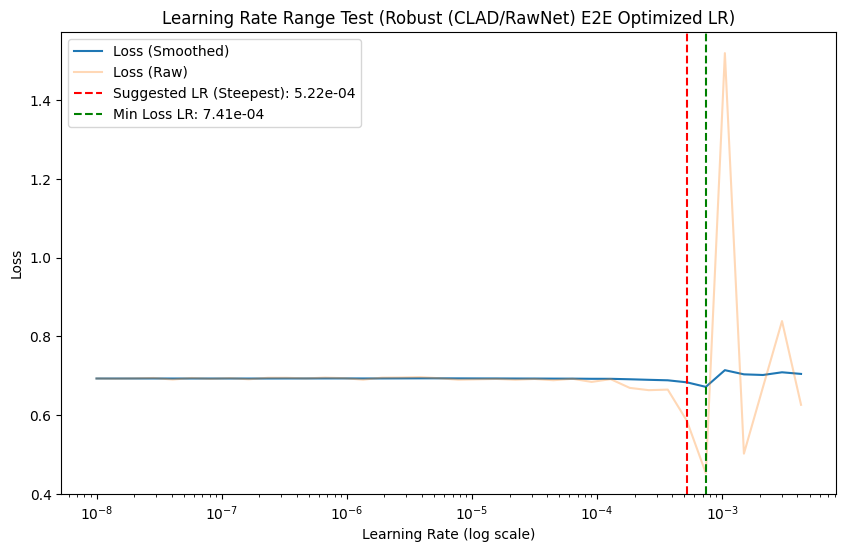


--- Part 2: Starts full training (Robust (CLAD/RawNet) E2E Optimized LR) with LR = 5.22e-04 ---
Starting Robust (CLAD/RawNet) E2E Optimized LR Training for 10 epochs on cuda.


Epoch 1/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   9%|▊         | 4/46 [00:01<00:10,  3.91it/s, acc=0.547, loss=0.6892]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   9%|▊         | 4/46 [00:01<00:10,  3.91it/s, acc=0.562, loss=0.6788]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  11%|█         | 5/46 [00:01<00:12,  3.41it/s, acc=0.562, loss=0.6788]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 1/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  17%|█▋        | 8/46 [00:02<00:08,  4.42i

Epoch 1/10 Summary | Train Loss: 0.3959, Acc: 0.819 | Val Loss: 0.1765, Acc: 0.943
  --> New best Robust (CLAD/RawNet) E2E Optimized LR model found. Saving checkpoint...


Epoch 2/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   4%|▍         | 2/46 [00:00<00:15,  2.92it/s, acc=0.938, loss=0.2016]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   9%|▊         | 4/46 [00:01<00:10,  3.88it/s, acc=0.930, loss=0.2094]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  11%|█         | 5/46 [00:01<00:12,  3.37it/s, acc=0.938, loss=0.2143]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 2/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  15%|█▌        | 7/46 [00:02<00:10,  3.64i

Epoch 2/10 Summary | Train Loss: 0.1987, Acc: 0.936 | Val Loss: 0.2870, Acc: 0.917


...

Epoch 8/10 Summary | Train Loss: 0.0244, Acc: 0.993 | Val Loss: 0.0651, Acc: 0.978


Epoch 9/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   4%|▍         | 2/46 [00:00<00:15,  2.79it/s, acc=1.000, loss=0.0031]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  13%|█▎        | 6/46 [00:01<00:09,  4.05it/s, acc=1.000, loss=0.0032]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  28%|██▊       | 13/46 [00:03<00:08,  3.86it/s, acc=0.998, loss=0.0143]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 9/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  30%|███       | 14/46 [00:03<00:06,  4.5

Epoch 9/10 Summary | Train Loss: 0.0280, Acc: 0.995 | Val Loss: 0.0661, Acc: 0.977


Epoch 10/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:   4%|▍         | 2/46 [00:00<00:14,  2.97it/s, acc=1.000, loss=0.0026]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
Epoch 10/10 [Train Robust (CLAD/RawNet) E2E Optimized LR]:  13%|█▎        | 6/46 [00:01<00:09,  4.40it/s, acc=1.000, loss=0.0022]/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.w

Epoch 10/10 Summary | Train Loss: 0.0258, Acc: 0.994 | Val Loss: 0.0709, Acc: 0.971

✅ Robust (CLAD/RawNet) E2E Optimized LR training complete with optimized LR of 5.22e-04.
Best model saved to: /content/best_robust_clad_model_optimized.pth


In [ ]:
  # cell 25: Robust CLAD/RawNet E2E With optimal LR
# =======================================================================

import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import math
import os
from tqdm import tqdm
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import sys

# --- 0. Auxiliary functions (recovery) ---

# Setting Focal Loss (to prevent errors if required later)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = torch.full_like(targets, 1-self.alpha, dtype=torch.float32)
        alpha_t[targets == 1] = self.alpha
        focal_loss = alpha_t * (1 - pt)**self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        else: return focal_loss

# Setting Length Loss (to prevent errors if required later)
class LengthLoss(nn.Module):
    def __init__(self, margin=4.0, weight=1.0):
        super(LengthLoss, self).__init__()
        self.margin = margin
        self.weight = weight
    def forward(self, features, targets):
        lengths = torch.norm(features, p=2, dim=1)
        loss_real = (1 - targets).float() * self.weight * lengths
        loss_fake = targets.float() * torch.clamp(self.margin - lengths, min=0.0)
        loss = (loss_real + loss_fake).mean()
        return loss

# LR Finder function
def find_optimal_lr(model_name, model_parts, test_criterion, train_loader, test_optimizer, model_forward_func):
    START_LR = 1e-8
    END_LR = 1e-1
    NUM_EPOCHS_TEST = 1
    NUM_BATCHES = len(train_loader) * NUM_EPOCHS_TEST

    lr_lambda = lambda x: math.exp(x * math.log(END_LR / START_LR) / NUM_BATCHES)
    lr_scheduler = torch.optim.lr_scheduler.LambdaLR(test_optimizer, lr_lambda)

    lrs_recorded = []
    losses_recorded = []
    best_loss = float('inf')

    train_iter = iter(train_loader)
    pbar_lr_test = tqdm(range(NUM_BATCHES), desc=f"LR Range Test ({model_name})")

    for batch_num in pbar_lr_test:
        try:
            (wavs, labels) = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            (wavs, labels) = next(train_iter)

        x, y = wavs.to(device).float(), labels.to(device).long()
        loss = model_forward_func(model_parts, test_criterion, x, y)

        current_loss = loss.item()
        if batch_num > 10 and (current_loss > 4 * best_loss or torch.isnan(loss)):
            print("Loss exploded, stopping LR test.")
            break
        if current_loss < best_loss and batch_num > 5:
            best_loss = current_loss

        test_optimizer.zero_grad()
        loss.backward()
        test_optimizer.step()

        lrs_recorded.append(test_optimizer.param_groups[0]['lr'])
        losses_recorded.append(current_loss)
        lr_scheduler.step()

    print(f"\n--- LR Range Test Analysis ({model_name}) ---")

    def smooth_curve(points, factor=0.1):
        smoothed_points = []
        for point in points:
            if smoothed_points:
                previous = smoothed_points[-1]
                smoothed_points.append(previous * (1.0 - factor) + point * factor)
            else:
                smoothed_points.append(point)
        return smoothed_points

    smoothed_losses = smooth_curve(losses_recorded, 0.05)
    log_lrs = [math.log10(lr) for lr in lrs_recorded]

    # Calculating gradient only on a stable part of the graph
    start_idx = min(10, len(lrs_recorded) - 1)
    if len(log_lrs) > start_idx + 1:
        gradients = np.gradient(smoothed_losses[start_idx:], log_lrs[start_idx:])
        steepest_grad_idx = np.argmin(gradients) + start_idx
        SUGGESTED_LR = lrs_recorded[steepest_grad_idx]
    else:
        # If there are not enough samples to calculate a gradient, we will use minimum loss
        min_loss_idx = np.argmin(smoothed_losses)
        SUGGESTED_LR = lrs_recorded[min_loss_idx]

    min_loss_idx = np.argmin(smoothed_losses)

    print(f"Minimum loss found in LR: {lrs_recorded[min_loss_idx]:.2e}")
    print(f"==> We will use the gradient value: {SUGGESTED_LR:.2e} for the full training.")

    plt.figure(figsize=(10, 6))
    plt.plot(lrs_recorded, smoothed_losses, label="Loss (Smoothed)")
    plt.plot(lrs_recorded, losses_recorded, alpha=0.3, label="Loss (Raw)")
    plt.axvline(x=SUGGESTED_LR, color='red', linestyle='--', label=f'Suggested LR (Steepest): {SUGGESTED_LR:.2e}')
    plt.axvline(x=lrs_recorded[min_loss_idx], color='green', linestyle='--', label=f'Min Loss LR: {lrs_recorded[min_loss_idx]:.2e}')
    plt.xscale('log')
    plt.xlabel('Learning Rate (log scale)')
    plt.ylabel('Loss')
    plt.title(f'Learning Rate Range Test ({model_name})')
    plt.legend()
    plt.show()

    return SUGGESTED_LR

print("✅ Auxiliary functions have been successfully restored.")

# --- 1. Settings (Step 1+2) ---
MODEL_NAME = "Robust (CLAD/RawNet) E2E Optimized LR"
MODEL_SAVE_PATH = "/content/best_robust_clad_model_optimized.pth"
EPOCHS = 10

# --- 2. Part 1: LR test ---
print(f"--- Part 1: Starting LR detection for {MODEL_NAME} ---")

try:
    # Make sure the CLAD library is available
    sys.path.append('/content/CLAD')
    from Model import RawNetEncoderBaseline
    sys.path.pop()

    test_encoder = RawNetEncoderBaseline(d_args, device).to(device)
    test_classifier = get_clad_classifier(D_CLAD).to(device)
    test_criterion = nn.CrossEntropyLoss()

    # Make sure we are using the correct DataLoaders (clad_train_ds)
    lr_test_loader = DataLoader(clad_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    test_optimizer = torch.optim.AdamW(
        list(test_encoder.parameters()) + list(test_classifier.parameters()),
        lr=1e-8,
        weight_decay=1e-4
    )

    def model_forward_e2e_test(model_parts, criterion, x, y):
        encoder, classifier = model_parts
        encoder.train()
        classifier.train()

        f = encoder(x)
        if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
        logits = classifier(f)
        return criterion(logits, y)

    SUGGESTED_LR = find_optimal_lr(
        MODEL_NAME,
        (test_encoder, test_classifier),
        test_criterion,
        lr_test_loader,
        test_optimizer,
        model_forward_e2e_test
    )
    del test_encoder, test_classifier, test_criterion, test_optimizer, lr_test_loader

except Exception as e:
    print(f"\n!!! Critical error locating LR: {e}. Make sure all global variables are loaded (d_args, D_CLAD, clad_train_ds) !!!")
    raise


# --- 4. Part 2: Full Training (E2E) ---
print(f"\n--- Part 2: Starts full training ({MODEL_NAME}) with LR = {SUGGESTED_LR:.2e} ---")

encoder_e2e = RawNetEncoderBaseline(d_args, device).to(device)
classifier_e2e = get_clad_classifier(D_CLAD).to(device)
criterion = nn.CrossEntropyLoss()
LR_CLAD_OPTIMIZED = SUGGESTED_LR

optimizer_e2e = torch.optim.AdamW(
    list(encoder_e2e.parameters()) + list(classifier_e2e.parameters()),
    lr=LR_CLAD_OPTIMIZED,
    weight_decay=1e-4
)

train_loader_final = DataLoader(clad_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_final = DataLoader(clad_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
scheduler_e2e = optim.lr_scheduler.CosineAnnealingLR(optimizer_e2e, T_max=EPOCHS * len(train_loader_final))

best_val_acc_e2e = 0.0

print(f"Starting {MODEL_NAME} Training for {EPOCHS} epochs on {device}.")
for epoch in range(1, EPOCHS + 1):
    encoder_e2e.train(); classifier_e2e.train()
    tr_loss = tr_correct = tr_total = 0.0
    train_pbar = tqdm(train_loader_final, desc=f"Epoch {epoch}/{EPOCHS} [Train {MODEL_NAME}]")

    for wavs, labels in train_pbar:
        x, y = wavs.to(device).float(), labels.to(device).long()

        f = encoder_e2e(x)
        if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
        logits = classifier_e2e(f)
        loss = criterion(logits, y)

        optimizer_e2e.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_e2e.step()
        scheduler_e2e.step()

        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(dim=1) == y).sum().item()
        tr_total += x.size(0)
        train_pbar.set_postfix(loss=f"{(tr_loss/tr_total):.4f}", acc=f"{(tr_correct/tr_total):.3f}")

    classifier_e2e.eval(); encoder_e2e.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    val_pbar = tqdm(val_loader_final, desc=f"Epoch {epoch}/{EPOCHS} [Val {MODEL_NAME}]")

    with torch.no_grad():
      for wavs, labels in val_pbar:
          x, y = wavs.to(device).float(), labels.to(device).long()
          f = encoder_e2e(x)
          if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
          logits = classifier_e2e(f)
          va_loss += criterion(logits, y).item() * x.size(0)
          va_correct += (logits.argmax(dim=1) == y).sum().item()
          va_total += x.size(0)
          val_pbar.set_postfix(loss=f"{(va_loss/va_total):.4f}", acc=f"{(va_correct/va_total):.3f}")

    current_val_acc = va_correct / va_total
    print(f"Epoch {epoch}/{EPOCHS} Summary | Train Loss: {tr_loss/tr_total:.4f}, Acc: {tr_correct/tr_total:.3f} | Val Loss: {va_loss/va_total:.4f}, Acc: {current_val_acc:.3f}")

    if current_val_acc > best_val_acc_e2e:
        print(f"  --> New best {MODEL_NAME} model found. Saving checkpoint...")
        best_val_acc_e2e = current_val_acc
        torch.save({
            'encoder_state_dict': encoder_e2e.state_dict(),
            'classifier_state_dict': classifier_e2e.state_dict(),
        }, MODEL_SAVE_PATH)

print(f"\n✅ {MODEL_NAME} training complete with optimized LR of {LR_CLAD_OPTIMIZED:.2e}.")
print(f"Best model saved to: {MODEL_SAVE_PATH}")

In [ ]:
# cell 26: CLAD E2E With feature noise
# =======================================================================

import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
import os
import sys
from torch.utils.data import DataLoader
import torch.nn.functional as F

# --- 0. Settings (since LR Finder is already running, we will use the LR found) ---
MODEL_NAME = "Robust (CLAD/RawNet) E2E + Feature Noise"
MODEL_SAVE_PATH = "/content/best_robust_clad_model_fn.pth"
EPOCHS = 10
LR_CLAD_OPTIMIZED = 5.22e-04 # We will use the optimal value found (you can change it to the value you received)
NOISE_STD = 0.05 # The intensity of the Gaussian noise added to the representation (Feature)

# --- 1. Loading CLAD and CNN (to ensure access to classes) ---
try:
    sys.path.append('/content/CLAD')
    from Model import RawNetEncoderBaseline
    sys.path.pop()
except ImportError:
    print("Error: Make sure CLAD is cloned and RawNetEncoderBaseline is accessible.")
    raise

# --- 2. Model initialization and Loaders ---
encoder_fn = RawNetEncoderBaseline(d_args, device).to(device)
classifier_fn = get_clad_classifier(D_CLAD).to(device)
criterion = nn.CrossEntropyLoss()

optimizer_fn = torch.optim.AdamW(
    list(encoder_fn.parameters()) + list(classifier_fn.parameters()),
    lr=LR_CLAD_OPTIMIZED,
    weight_decay=1e-4
)

train_loader_final = DataLoader(clad_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_final = DataLoader(clad_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
scheduler_fn = optim.lr_scheduler.CosineAnnealingLR(optimizer_fn, T_max=EPOCHS * len(train_loader_final))

best_val_acc_fn = 0.0

# --- 3. Training loop with Feature Noise ---
print(f"\nStarting {MODEL_NAME} Training for {EPOCHS} epochs on {device} (Noise STD: {NOISE_STD}).")
for epoch in range(1, EPOCHS + 1):
    encoder_fn.train(); classifier_fn.train()
    tr_loss = tr_correct = tr_total = 0.0
    train_pbar = tqdm(train_loader_final, desc=f"Epoch {epoch}/{EPOCHS} [Train {MODEL_NAME}]")

    for wavs, labels in train_pbar:
        x, y = wavs.to(device).float(), labels.to(device).long()

        f = encoder_fn(x)
        if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))

        # *** New enhancement: Feature Noise ***
        # Adds Gaussian noise to the f representation
        noise = torch.randn_like(f) * NOISE_STD
        f_noisy = f + noise

        logits = classifier_fn(f_noisy)
        loss = criterion(logits, y)

        optimizer_fn.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_fn.step()
        scheduler_fn.step()

        tr_loss += loss.item() * x.size(0)
        tr_correct += (logits.argmax(dim=1) == y).sum().item()
        tr_total += x.size(0)
        train_pbar.set_postfix(loss=f"{(tr_loss/tr_total):.4f}", acc=f"{(tr_correct/tr_total):.3f}")

    # Evaluation (without Feature Noise)
    classifier_fn.eval(); encoder_fn.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    val_pbar = tqdm(val_loader_final, desc=f"Epoch {epoch}/{EPOCHS} [Val {MODEL_NAME}]")

    with torch.no_grad():
      for wavs, labels in val_pbar:
          x, y = wavs.to(device).float(), labels.to(device).long()
          f = encoder_fn(x)
          if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
          # Evaluation is always performed on the clean representation (f)
          logits = classifier_fn(f)
          va_loss += criterion(logits, y).item() * x.size(0)
          va_correct += (logits.argmax(dim=1) == y).sum().item()
          va_total += x.size(0)
          val_pbar.set_postfix(loss=f"{(va_loss/va_total):.4f}", acc=f"{(va_correct/va_total):.3f}")

    current_val_acc = va_correct / va_total
    print(f"Epoch {epoch}/{EPOCHS} Summary | Train Loss: {tr_loss/tr_total:.4f}, Acc: {tr_correct/tr_total:.3f} | Val Loss: {va_loss/va_total:.4f}, Acc: {current_val_acc:.3f}")

    if current_val_acc > best_val_acc_fn:
        print(f"  --> New best {MODEL_NAME} model found. Saving checkpoint...")
        best_val_acc_fn = current_val_acc
        torch.save({
            'encoder_state_dict': encoder_fn.state_dict(),
            'classifier_state_dict': classifier_fn.state_dict(),
        }, MODEL_SAVE_PATH)

print(f"\n✅ {MODEL_NAME} training complete with optimized LR of {LR_CLAD_OPTIMIZED:.2e}.")
print(f"Best model saved to: {MODEL_SAVE_PATH}")


Starting Robust (CLAD/RawNet) E2E + Feature Noise Training for 10 epochs on cuda (Noise STD: 0.05).


Epoch 1/10 [Train Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 46/46 [00:27<00:00,  1.67it/s, acc=0.817, loss=0.4452]
Epoch 1/10 [Val Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 23/23 [00:12<00:00,  1.87it/s, acc=0.724, loss=0.7158]


Epoch 1/10 Summary | Train Loss: 0.4452, Acc: 0.817 | Val Loss: 0.7158, Acc: 0.724
  --> New best Robust (CLAD/RawNet) E2E + Feature Noise model found. Saving checkpoint...


Epoch 2/10 [Train Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 46/46 [00:26<00:00,  1.73it/s, acc=0.965, loss=0.1489]
Epoch 2/10 [Val Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 23/23 [00:11<00:00,  1.95it/s, acc=0.967, loss=0.1028]


Epoch 2/10 Summary | Train Loss: 0.1489, Acc: 0.965 | Val Loss: 0.1028, Acc: 0.967
  --> New best Robust (CLAD/RawNet) E2E + Feature Noise model found. Saving checkpoint...


...

Epoch 8/10 Summary | Train Loss: 0.0286, Acc: 0.995 | Val Loss: 0.0233, Acc: 0.990
  --> New best Robust (CLAD/RawNet) E2E + Feature Noise model found. Saving checkpoint...


Epoch 9/10 [Train Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 46/46 [00:26<00:00,  1.71it/s, acc=0.995, loss=0.0284]
Epoch 9/10 [Val Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 23/23 [00:12<00:00,  1.86it/s, acc=0.993, loss=0.0196]


Epoch 9/10 Summary | Train Loss: 0.0284, Acc: 0.995 | Val Loss: 0.0196, Acc: 0.993
  --> New best Robust (CLAD/RawNet) E2E + Feature Noise model found. Saving checkpoint...


Epoch 10/10 [Train Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 46/46 [00:26<00:00,  1.70it/s, acc=0.995, loss=0.0238]
Epoch 10/10 [Val Robust (CLAD/RawNet) E2E + Feature Noise]: 100%|██████████| 23/23 [00:12<00:00,  1.89it/s, acc=0.990, loss=0.0290]

Epoch 10/10 Summary | Train Loss: 0.0238, Acc: 0.995 | Val Loss: 0.0290, Acc: 0.990

✅ Robust (CLAD/RawNet) E2E + Feature Noise training complete with optimized LR of 5.22e-04.
Best model saved to: /content/best_robust_clad_model_fn.pth


In [ ]:
# cell 27: LOADING MODELS AND RUNNING TESTS
# =======================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import pandas as pd
import os
import shutil
from tqdm import tqdm
from pathlib import Path
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torchaudio
import pyloudnorm as pyln
import random
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
warnings.filterwarnings("ignore")

# --- 0. Basic settings ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running evaluation on device: {device}")
SEED = int(time.time())
TARGET_SR = 16000
TARGET_LEN = 64600
TARGET_LUFS = -23.0
BATCH_SIZE = 32
NUM_WORKERS = 0 # Must be 0 to prevent crashes

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- 1. Recreating the static test set ---
CLEAN_TEST_ROOT = Path("/content/my_audio_split/test")
ATTACKED_TEST_ROOT = Path("/content/my_audio_split_attacked_test")

print(f"\n--- Step 1: Create a test set that is attacked by: {ATTACKED_TEST_ROOT} ---")

if ATTACKED_TEST_ROOT.exists():
    print("Deleting old test folder...")
    shutil.rmtree(ATTACKED_TEST_ROOT)

ATTACKED_TEST_ROOT.mkdir(parents=True, exist_ok=True)
(ATTACKED_TEST_ROOT / "real").mkdir(parents=True, exist_ok=True)
(ATTACKED_TEST_ROOT / "fake").mkdir(parents=True, exist_ok=True)

def process_file(src_path, dst_path):
    try:
        wav, sr = torchaudio.load(str(src_path))
        wav = normalize_lufs_torch(wav, sr, TARGET_LUFS)
        # Using a function that chooses from the 3 augmentations
        wav_aug = apply_single_attack(wav, sr)
        torchaudio.save(str(dst_path), wav_aug, TARGET_SR)
        return True
    except Exception as e:
        return False

clean_files = list(CLEAN_TEST_ROOT.rglob("*.wav"))
jobs = []
for src in clean_files:
    rel = src.relative_to(CLEAN_TEST_ROOT)
    dst = ATTACKED_TEST_ROOT / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    jobs.append((src, dst))

print(f"Generates attacks for {len(jobs)} Files...")
success_count = 0
# ThreadPool
with ThreadPoolExecutor(max_workers=2) as ex:
    futures = [ex.submit(process_file, src, dst) for src, dst in jobs]
    for f in tqdm(as_completed(futures), total=len(jobs), desc="Generating Attacks"):
        if f.result(): success_count += 1

print(f"Finishing work: {success_count}/{len(jobs)} Files created.")

# --- 2. Loading DataLoaders ---
print("\n--- Step 2: Loading DataLoaders ---")

# Dataset settings
LABELS = {"real": 0, "fake": 1}

class FlexibleAudioDataset(Dataset):
    def __init__(self, root_dir, augmentation_mode='none', train_mode=False, apply_z_norm=False):
        self.samples = []
        self.apply_z_norm = apply_z_norm
        for cls in ("real", "fake"):
            path = Path(root_dir) / cls
            if path.exists():
                for p in path.rglob("*.wav"): self.samples.append((p, LABELS[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p, lbl = self.samples[idx]
        try:
            wav, sr = torchaudio.load(str(p))
            wav = pad_trim(wav, TARGET_LEN)
            if self.apply_z_norm: wav = (wav - wav.mean()) / (wav.std() + 1e-6)
            return wav.squeeze(0), torch.tensor(lbl)
        except: return torch.zeros(TARGET_LEN), torch.tensor(lbl)

class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, augmentation_mode='none', train_mode=False):
        self.samples = []
        for cls in ("real", "fake"):
            path = Path(root_dir) / cls
            if path.exists():
                for p in path.rglob("*.wav"): self.samples.append((p, LABELS[cls]))
        self.mel = T.MelSpectrogram(sample_rate=TARGET_SR, n_fft=400, hop_length=160, n_mels=128, power=2.0)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p, lbl = self.samples[idx]
        try:
            wav, sr = torchaudio.load(str(p))
            wav = pad_trim(wav, TARGET_LEN)
            spec = torch.log(self.mel(wav) + 1e-6)
            return spec, torch.tensor(lbl)
        except: return torch.zeros(1, 128, 404), torch.tensor(lbl)

# Creating Loaders
clad_loader_clean = DataLoader(FlexibleAudioDataset(str(CLEAN_TEST_ROOT), apply_z_norm=True), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
clad_loader_attacked = DataLoader(FlexibleAudioDataset(str(ATTACKED_TEST_ROOT), apply_z_norm=True), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

cnn_loader_clean = DataLoader(SpectrogramDataset(str(CLEAN_TEST_ROOT)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
cnn_loader_attacked = DataLoader(SpectrogramDataset(str(ATTACKED_TEST_ROOT)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# --- 3. Loading the models ---
print("\n--- Step 3: Loading all models---")
# Make sure CLAD is available
try:
    os.chdir('/content/CLAD')
    from Model import RawNetEncoderBaseline
    os.chdir('/content/')
except: pass

d_args = {"in_channels": 1, "first_conv": 251, "filts": [32, [32, 32], [32, 64], [64, 64]], "nb_fc_node": 1024, "gru_node": 1024, "nb_gru_layer": 3, "nb_classes": 2}
D_CLAD = 1024
def get_clad_classifier(input_dim=D_CLAD): return nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 2))

# Charging functions
def load_clad(path):
    try:
        enc = RawNetEncoderBaseline(d_args, device).to(device)
        cls = get_clad_classifier(D_CLAD).to(device)
        ckpt = torch.load(path, map_location=device)
        enc.load_state_dict(ckpt['encoder_state_dict'])
        cls.load_state_dict(ckpt['classifier_state_dict'])
        enc.eval(); cls.eval()
        return enc, cls
    except Exception as e:
        print(f"Warning: Could not load CLAD model from {path}. Error: {e}")
        return None, None

class SpectrogramCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.conv_block2 = nn.Sequential(nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.conv_block3 = nn.Sequential(nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.flatten_size = 64 * 16 * 50
        self.flatten = nn.Flatten()
        self.fc_block = nn.Sequential(nn.Linear(self.flatten_size, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, 2))
    def forward(self, x):
        x = self.conv_block1(x); x = self.conv_block2(x); x = self.conv_block3(x)
        x = self.flatten(x); return self.fc_block(x)

def load_cnn(path):
    try:
        model = SpectrogramCNN().to(device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()
        return model
    except Exception as e:
        print(f"Warning: Could not load CNN model from {path}. Error: {e}")
        return None

# Actual loading
MODELS_TO_EVAL = [
    {'id': 'Robust_CNN', 'path': '/content/best_cnn_robust_model.pth', 'type': 'cnn', 'name': 'Robust CNN'},
    {'id': 'CLAD_Base', 'path': '/content/best_robust_clad_model.pth', 'type': 'clad', 'name': 'Base CLAD/RawNet'},
    {'id': 'CLAD_Focal', 'path': '/content/best_clad_focal_optimized.pth', 'type': 'clad', 'name': 'CLAD + Focal (Opt LR)'},
    {'id': 'CLAD_LL', 'path': '/content/best_clad_ll_optimized.pth', 'type': 'clad', 'name': 'CLAD + Length (Opt LR)'},
    {'id': 'CLAD_Opt_LR', 'path': '/content/best_robust_clad_model_optimized.pth', 'type': 'clad', 'name': 'CLAD Optimized LR'},
    {'id': 'CLAD_FN', 'path': '/content/best_robust_clad_model_fn.pth', 'type': 'clad', 'name': 'CLAD + Feature Noise'},
    {'id': 'Baseline_CNN', 'path': '/content/best_cnn_model.pth', 'type': 'cnn', 'name': 'Baseline CNN'}
]

loaded_models = []
for m_config in MODELS_TO_EVAL:
    model_obj = None
    if m_config['type'] == 'clad':
        enc, cls = load_clad(m_config['path'])
        if enc and cls: model_obj = (enc, cls)
    elif m_config['type'] == 'cnn':
        model_obj = load_cnn(m_config['path'])

    if model_obj:
        loaded_models.append({
            'id': m_config['id'],
            'name': m_config['name'],
            'type': m_config['type'],
            'model': model_obj
        })
        print(f"✅ Loaded: {m_config['name']}")

# --- 4. Running the tests ---
print("\n--- Step 4: Run the assessment---")

def clad_predict(enc, cls, x):
    f = enc(x)
    if f.dim() > 2: f = f.mean(dim=tuple(range(2, f.dim())))
    return cls(f)

def evaluate_dataset(models_list, clad_loader, cnn_loader, dataset_name):
    individual_results = []
    all_probs_per_model = {}

    for m in models_list:
        name = m['name']
        m_type = m['type']
        model_obj = m['model']

        loader = cnn_loader if m_type == 'cnn' else clad_loader

        all_preds, all_labels = [], []
        model_probs = []

        with torch.no_grad():
            for x, y in tqdm(loader, desc=f"Testing {name} on {dataset_name}", leave=False):
                x = x.to(device).float()
                y = y.to(device).long()

                if m_type == 'clad':
                    enc, cls = model_obj
                    logits = clad_predict(enc, cls, x)
                else: # cnn
                    logits = model_obj(x)

                probs = F.softmax(logits, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                model_probs.append(probs.cpu())

        if not all_labels: # Skip if no data
            print(f"Warning: No data for {name} on {dataset_name}.")
            continue

        # Calculating metrics
        acc = accuracy_score(all_labels, all_preds)
        p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', pos_label=1)

        individual_results.append({
            "Model": name,
            "Test Set": dataset_name,
            "Accuracy": acc,
            "Fake Precision": p,
            "Fake Recall": r,
            "Fake F1": f1,
            "Probs": torch.cat(model_probs) if model_probs else torch.tensor([])
        })
        # Store all_labels once, they should be the same across models for the same loader
        if not all_probs_per_model: # only once
            all_probs_per_model['labels'] = all_labels
        all_probs_per_model[name] = torch.cat(model_probs) if model_probs else torch.tensor([])

    return individual_results, all_probs_per_model, all_labels # Return all_labels with probs

# --- 3. Running ---
try:
    # Evaluate on CLEAN data
    print("\n Running evaluation on CLEAN Data...")
    clean_results_list, _, _ = evaluate_dataset(loaded_models, clad_loader_clean, cnn_loader_clean, "Clean")

    # Evaluate on ATTACKED data
    print("\n Running evaluation on ATTACKED Data...")
    attacked_results_list, all_attacked_probs, attacked_labels = evaluate_dataset(loaded_models, clad_loader_attacked, cnn_loader_attacked, "Attacked (Hard)")

    # Combine all results for the final DataFrame
    final_results = clean_results_list + attacked_results_list

    df_final = pd.DataFrame(final_results)

    # Drop the 'Probs' column before displaying
    if 'Probs' in df_final.columns:
        df_final = df_final.drop(columns=["Probs"])

    # Design
    for col in ["Accuracy", "Fake Precision", "Fake Recall", "Fake F1"]:
        df_final[col] = (df_final[col] * 100).round(2).astype(str) + '%'

    print("\n" + "="*80)
    print("🏆 FINAL RESULTS TABLE (Comparing your models to each other) 🏆")
    print("="*80)
    print(df_final.to_string(index=False))
    print("="*80)

except NameError as e:
    print(f"!!!Error: Loaders or other variables are not defined. Run the previous cells. Error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Running evaluation on device: cuda

--- Step 1: Create a test set that is attacked by: /content/my_audio_split_attacked_test ---
Deleting old test folder...
Generates attacks for 462 Files...


Generating Attacks: 100%|██████████| 462/462 [00:06<00:00, 70.84it/s]


Finishing work: 462/462 Files created.

--- Step 2: Loading DataLoaders ---

--- Step 3: Loading all models---
✅ Loaded: Robust CNN
✅ Loaded: Base CLAD/RawNet
✅ Loaded: CLAD + Focal (Opt LR)
✅ Loaded: CLAD + Length (Opt LR)
✅ Loaded: CLAD Optimized LR
✅ Loaded: CLAD + Feature Noise
✅ Loaded: Baseline CNN

--- Step 4: Run the assessment---

 Running evaluation on CLEAN Data...



 Running evaluation on ATTACKED Data...



🏆 FINAL RESULTS TABLE (Comparing your models to each other) 🏆
                 Model        Test Set Accuracy Fake Precision Fake Recall Fake F1
            Robust CNN           Clean    97.4%          96.2%       98.7%  97.44%
      Base CLAD/RawNet           Clean   93.94%         95.93%      91.77%  93.81%
 CLAD + Focal (Opt LR)           Clean   94.16%         93.22%      95.24%  94.22%
CLAD + Length (Opt LR)           Clean   91.34%         95.26%      87.01%  90.95%
     CLAD Optimized LR           Clean   95.02%         95.61%      94.37%  94.99%
  CLAD + Feature Noise           Clean   96.54%         94.61%       98.7%  96.61%
          Baseline CNN           Clean    97.4%          96.2%       98.7%  97.44%
            Robust CNN Attacked (Hard)    67.1%          68.2%      64.07%  66.07%
      Base CLAD/RawNet Attacked (Hard)   88.53%         96.84%      79.65%  87.41%
 CLAD + Focal (Opt LR) Attacked (Hard)   88.96%         89.82%      87.88%  88.84%
CLAD + Length (Opt LR) A

Running t-SNE for 7 models on ATTACKED data...



Processing complete. Generating refined plots...


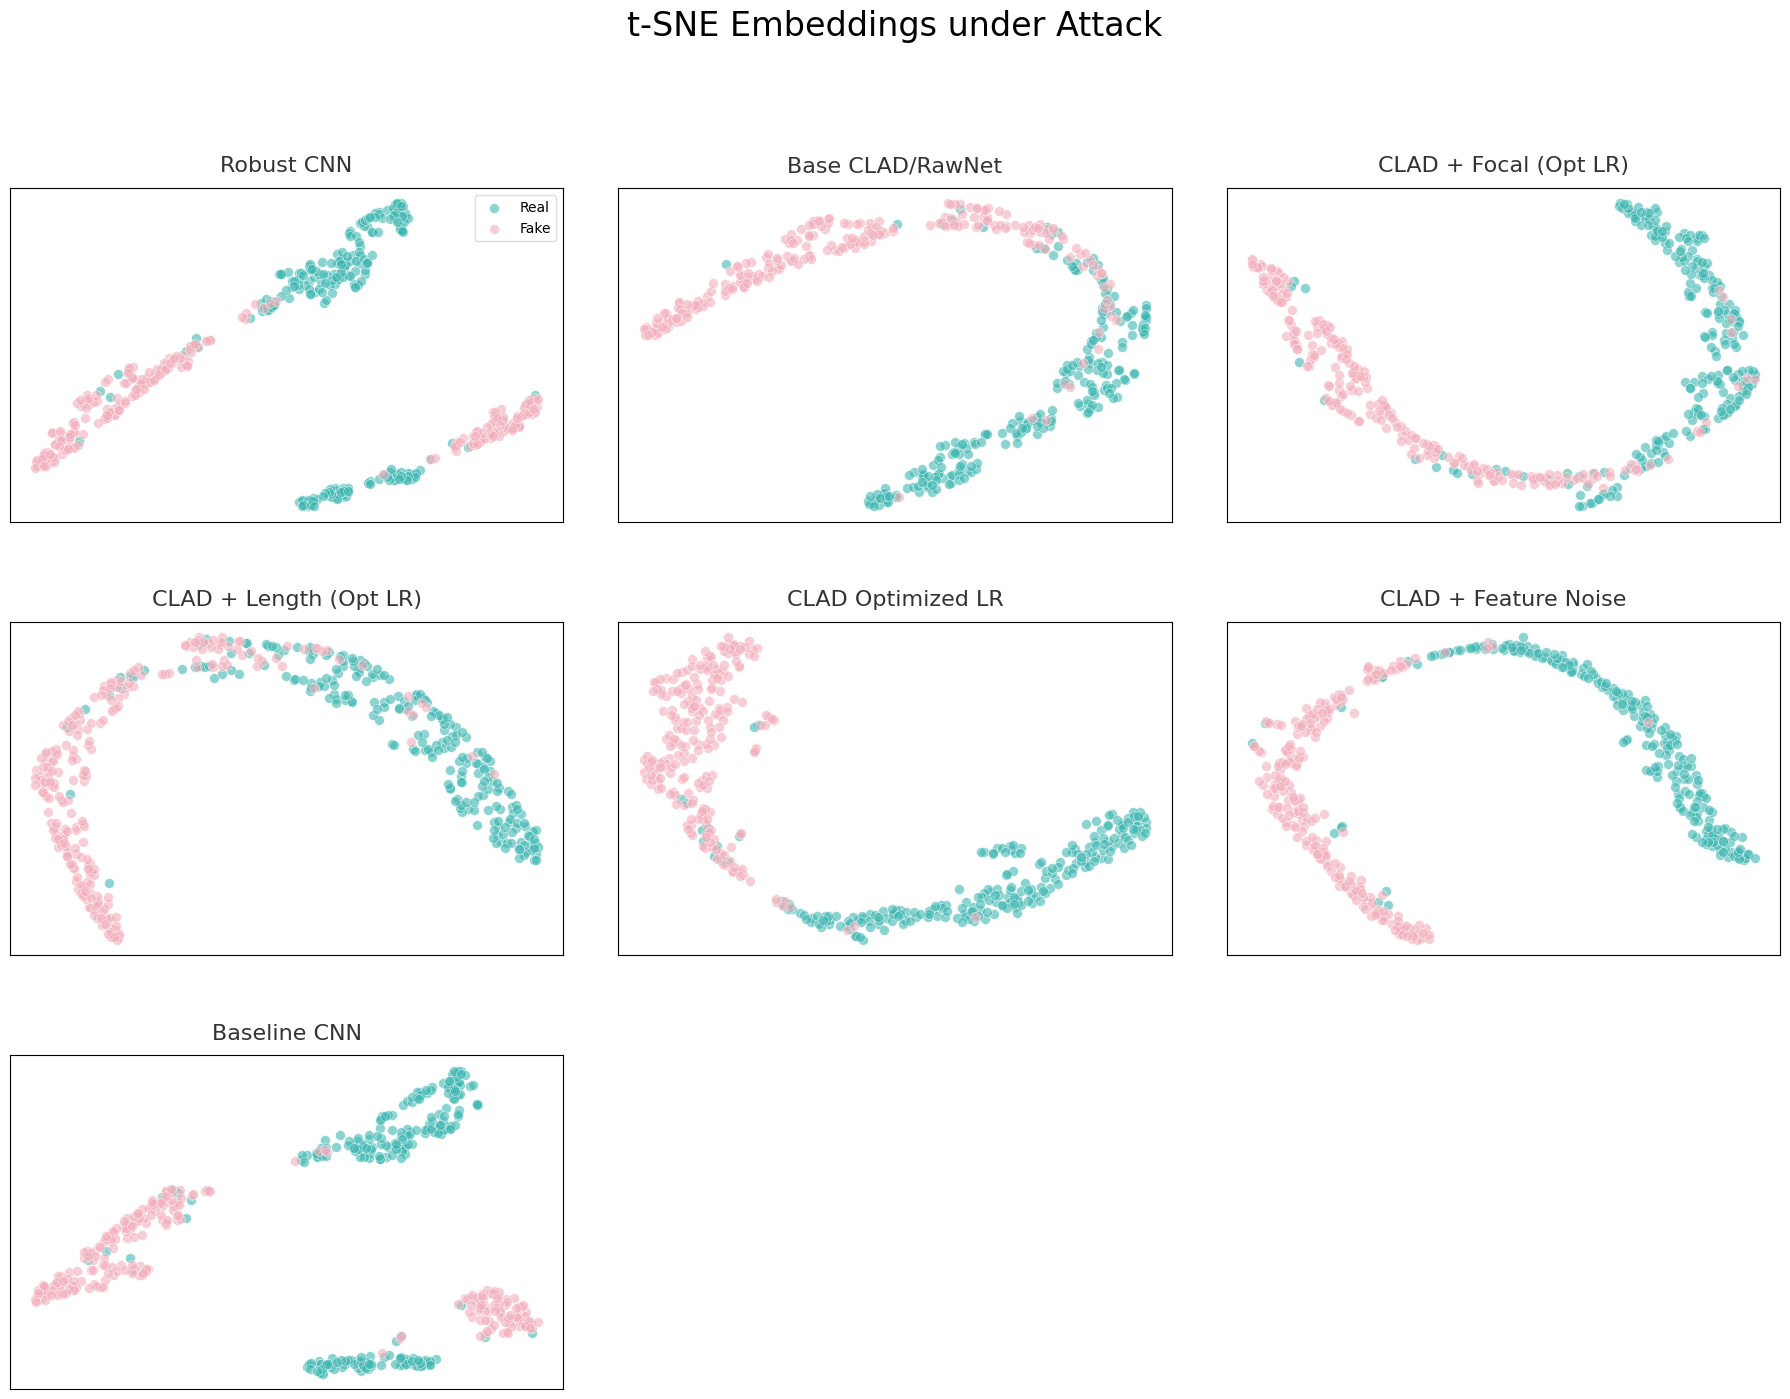

In [48]:
# # Cell 31: Visual Comparison (t-SNE) - Polished & English Comments
# # =================================================================
# # 🎨 t-SNE Visual Comparison: Styled Layout & English Comments
# # =================================================================
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
import math

# --- Configuration ---
MAX_SAMPLES = 1000  # Limit samples to speed up t-SNE (0 = no limit)
PERPLEXITY_VAL = 30
SEED = 42

# --- Pastel Color Palette ---
COLOR_REAL = '#3DB6B1'  # Soft Blue
COLOR_FAKE = '#F2AEBB'  # Soft Red (Salmon)

print(f"Running t-SNE for {len(loaded_models)} models on ATTACKED data...")

# --- 1. Feature Extraction Helper Function ---
def extract_features(model_entry, clad_loader, cnn_loader):
    """
    Extracts embeddings (feature vectors) from a model.
    Handles the architectural differences between CLAD (Encoder) and CNN.
    """
    model_type = model_entry['type']
    model_obj = model_entry['model']
    name = model_entry['name']

    # Select the correct loader based on model type
    loader = cnn_loader if model_type == 'cnn' else clad_loader

    all_embeddings = []
    all_labels = []

    # Set model to evaluation mode (just in case)
    # Note: We manually extract features, so we don't call .eval() on the wrapper here,
    # but the sub-modules should already be in eval mode from loading.

    with torch.no_grad():
        count = 0
        for data, labels in tqdm(loader, desc=f"Extracting {name}", leave=False):
            data = data.to(device).float()

            if model_type == 'clad':
                # CLAD model is a tuple: (encoder, classifier)
                enc, _ = model_obj
                feats = enc(data)
                # Perform mean pooling if output is 3D (Batch, Channels, Time)
                if feats.dim() > 2:
                    feats = feats.mean(dim=tuple(range(2, feats.dim())))

            elif model_type == 'cnn':
                # Manually forward pass through CNN layers up to the penultimate layer
                x = model_obj.conv_block1(data)
                x = model_obj.conv_block2(x)
                x = model_obj.conv_block3(x)
                x = model_obj.flatten(x)
                # Access the first Linear layer inside the fc_block sequence
                x = model_obj.fc_block[0](x)
                # Access the ReLU activation
                feats = model_obj.fc_block[1](x)

            all_embeddings.append(feats.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

            count += len(labels)
            if MAX_SAMPLES > 0 and count >= MAX_SAMPLES:
                break

    X = np.vstack(all_embeddings)
    y = np.concatenate(all_labels)

    # Convert numeric labels to string for easier plotting
    y_str = np.array(["real" if l == 0 else "fake" for l in y])
    return X, y_str

# --- 2. Main Loop: Calculate t-SNE for each model ---
tsne_results = []

for m in loaded_models:
    # A. Extract Features
    X, y_labels = extract_features(m, clad_loader_attacked, cnn_loader_attacked)

    # B. Run t-SNE (only if enough samples exist)
    if len(X) > PERPLEXITY_VAL:
        # print(f"Calculating t-SNE for {m['name']}...") # Optional verbose
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=PERPLEXITY_VAL, init='random', learning_rate='auto')
        X_embedded = tsne.fit_transform(X)

        tsne_results.append({
            "name": m['name'],
            "X_tsne": X_embedded,
            "y_labels": y_labels
        })
    else:
        print(f"Skipping {m['name']} - not enough samples for perplexity {PERPLEXITY_VAL}.")

print("\nProcessing complete. Generating refined plots...")

# --- 3. Visualization: Create the Grid ---
num_models = len(tsne_results)
cols = 3  # Reduced to 3 columns for larger, clearer graphs
rows = math.ceil(num_models / cols)

# Set a cleaner style
plt.style.use('default')

# Create Figure with generous size
fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
fig.suptitle(f't-SNE Embeddings under Attack\n', fontsize=24, fontweight='light', y=0.96)

axs_flat = axs.flatten()

for i, res in enumerate(tsne_results):
    ax = axs_flat[i]
    X2d = res['X_tsne']
    y_lbl = res['y_labels']
    name = res['name']

    # Plot Real samples
    mask_real = (y_lbl == "real")
    ax.scatter(X2d[mask_real,0], X2d[mask_real,1],
               c=COLOR_REAL, label="Real",
               alpha=0.6, s=50, edgecolor='white', linewidth=0.5)

    # Plot Fake samples
    mask_fake = (y_lbl == "fake")
    ax.scatter(X2d[mask_fake,0], X2d[mask_fake,1],
               c=COLOR_FAKE, label="Fake",
               alpha=0.6, s=50, edgecolor='white', linewidth=0.5)

    # -- Styling the individual plot --
    ax.set_title(name, fontsize=16, fontweight='medium', pad=12, color='#333333')

    # Add a subtle grid
    ax.grid(True, linestyle=':', alpha=0.4, color='gray')

    # Remove axis ticks (numbers) for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove top and right spines (borders)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_color("black")
    ax.spines['bottom'].set_color("black")

    # Add legend only to the first plot
    if i == 0:
        leg = ax.legend(loc='upper right', frameon=True, fancybox=True, framealpha=0.95, fontsize=10)
        leg.get_frame().set_edgecolor('#DDDDDD')

# Hide empty subplots
for j in range(i + 1, len(axs_flat)):
    axs_flat[j].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.subplots_adjust(wspace=0.1, hspace=0.3) # Add extra breathing room

plt.show()